# Workflow 与 agent

本指南梳理常见的 workflow 与 agent 模式。

- Workflow 的代码路径是预先确定的, 并按特定顺序运行。
- Agent 是动态的, 它们自行决定流程与 tool 的使用方式。

![Agent Workflow](https://docs.langchain.com/oss/images/agent_workflow.png)

在构建 agents 与 workflows 时, LangGraph 提供了多项优势, 包括 [persistence](https://docs.langchain.com/oss/langgraph/persistence)、[streaming](https://docs.langchain.com/oss/langgraph/streaming), 以及对调试与 [部署](https://docs.langchain.com/oss/langgraph/deploy) 的支持。

In [1]:
# 环境准备: 从 .env 加载 API keys
from dotenv import load_dotenv

load_dotenv()  # 自动向上查找仓库根目录的 .env

# ---- 统一导入 ----
import operator
from dataclasses import dataclass
from typing import Annotated, List, Literal

from typing_extensions import TypedDict

from IPython.display import Image, Markdown, display
from langchain.chat_models import init_chat_model
from langchain.messages import (
    AIMessage,
    HumanMessage,
    SystemMessage,
    ToolCall,
    ToolMessage,
)
from langchain.tools import ToolRuntime, tool
from langchain_core.messages import BaseMessage
from langgraph.func import entrypoint, task
from langgraph.graph import END, START, MessagesState, StateGraph, add_messages
from langgraph.prebuilt import ToolNode
from langgraph.types import Send
from pydantic import BaseModel, Field

## 环境准备

构建 workflow 或 agent 时, 你可以使用[任何支持结构化输出与 tool calling 的 chat model](https://docs.langchain.com/oss/integrations/chat)。下面的示例使用 DeepSeek 的 chat model。

In [2]:
llm = init_chat_model("deepseek:deepseek-chat", temperature=0)

## LLM 与增强

Workflows 与 agentic 系统都以 LLM 以及你为其添加的各种增强能力为基础。[Tool calling](https://docs.langchain.com/oss/langchain/tools)、[structured outputs](https://docs.langchain.com/oss/langchain/structured-output) 与 [short term memory](https://docs.langchain.com/oss/langchain/short-term-memory) 只是按需定制 LLM 的几种可选手段。

![LLM augmentations](https://docs.langchain.com/oss/images/augmented_llm.png)

In [3]:
# Schema for structured output
class SearchQuery(BaseModel):
    search_query: str | None = Field(
        default=None, description="Query that is optimized web search."
    )
    justification: str | None = Field(
        default=None, description="Why this query is relevant to the user's request."
    )


# Augment the LLM with schema for structured output
structured_llm = llm.with_structured_output(SearchQuery)

# Invoke the augmented LLM
output = structured_llm.invoke("How does Calcium CT score relate to high cholesterol?")
print(output)  # The model returns an instance of SearchQuery.

# Define a tool
def multiply(a: int, b: int) -> int:
    return a * b

# Augment the LLM with tools
llm_with_tools = llm.bind_tools([multiply])

# Invoke the LLM with input that triggers the tool call
msg = llm_with_tools.invoke("What is 2 times 3?")
print(msg.tool_calls)  # The model returns a request to call the tool.

search_query='coronary artery calcium score relationship with high cholesterol' justification='To find medical evidence on how coronary calcium CT scores relate to elevated cholesterol levels.'


[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'call_00_APwMOvplwOuaQkc03bYY9925', 'type': 'tool_call'}]


## Prompt chaining

Prompt chaining 指的是每一次 LLM 调用都处理上一次调用的输出。它常用于执行那些可以拆解成更小、可验证步骤的明确定义的任务。示例如下:

- 把文档翻译成不同语言
- 校验生成内容的一致性

![Prompt chaining](https://docs.langchain.com/oss/images/prompt_chain.png)

### Graph API

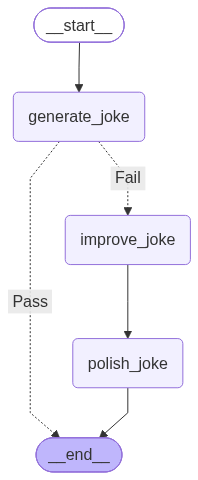

Initial joke:
Why did the cat join a band?

Because it wanted to be the purr-cussionist!

--- --- ---

Final joke:
Why did the cat join a band?

Because it wanted to be the purr-cussionist!


In [4]:
# Graph state
class State(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str


# Nodes
def generate_joke(state: State):
    """First LLM call to generate initial joke"""

    msg = llm.invoke(f"Write a short joke about {state['topic']}")
    return {"joke": msg.content}


def check_punchline(state: State):
    """Gate function to check if the joke has a punchline"""

    # Simple check - does the joke contain "?" or "!"
    if "?" in state["joke"] or "!" in state["joke"]:
        return "Pass"
    return "Fail"


def improve_joke(state: State):
    """Second LLM call to improve the joke"""

    msg = llm.invoke(f"Make this joke funnier by adding wordplay: {state['joke']}")
    return {"improved_joke": msg.content}


def polish_joke(state: State):
    """Third LLM call for final polish"""

    msg = llm.invoke(f"Add a surprising twist to this joke: {state['improved_joke']}")
    return {"final_joke": msg.content}


# Build workflow
workflow = StateGraph(State)

# Add nodes
workflow.add_node("generate_joke", generate_joke)
workflow.add_node("improve_joke", improve_joke)
workflow.add_node("polish_joke", polish_joke)

# Add edges to connect nodes
workflow.add_edge(START, "generate_joke")
workflow.add_conditional_edges(
    "generate_joke", check_punchline, {"Fail": "improve_joke", "Pass": END}
)
workflow.add_edge("improve_joke", "polish_joke")
workflow.add_edge("polish_joke", END)

# Compile
chain = workflow.compile()

# Show workflow
display(Image(chain.get_graph().draw_mermaid_png()))

# Invoke
state = chain.invoke({"topic": "cats"})
print("Initial joke:")
print(state["joke"])
print("\n--- --- ---\n")
if "improved_joke" in state:
    print("Improved joke:")
    print(state["improved_joke"])
    print("\n--- --- ---\n")

    print("Final joke:")
    print(state["final_joke"])
else:
    print("Final joke:")
    print(state["joke"])

### Functional API

In [5]:
# Tasks
@task
def generate_joke(topic: str):
    """First LLM call to generate initial joke"""
    msg = llm.invoke(f"Write a short joke about {topic}")
    return msg.content


def check_punchline(joke: str):
    """Gate function to check if the joke has a punchline"""
    # Simple check - does the joke contain "?" or "!"
    if "?" in joke or "!" in joke:
        return "Fail"

    return "Pass"


@task
def improve_joke(joke: str):
    """Second LLM call to improve the joke"""
    msg = llm.invoke(f"Make this joke funnier by adding wordplay: {joke}")
    return msg.content


@task
def polish_joke(joke: str):
    """Third LLM call for final polish"""
    msg = llm.invoke(f"Add a surprising twist to this joke: {joke}")
    return msg.content


@entrypoint()
def prompt_chaining_workflow(topic: str):
    original_joke = generate_joke(topic).result()
    if check_punchline(original_joke) == "Pass":
        return original_joke

    improved_joke = improve_joke(original_joke).result()
    return polish_joke(improved_joke).result()

# Invoke
stream = prompt_chaining_workflow.stream_events("cats", version="v3")
for snapshot in stream.values:
    print(snapshot)
    print("\n")

C:\Users\Ashit\Documents\GitHub\LangChain-Docs\.venv\Lib\site-packages\langgraph\pregel\main.py:3708: LangChainBetaWarning: The v3 streaming protocol on Pregel is experimental.
  return self._pregel_stream_v3(
C:\Users\Ashit\Documents\GitHub\LangChain-Docs\.venv\Lib\site-packages\langgraph\pregel\main.py:3558: LangChainBetaWarning: The v3 streaming protocol on Pregel is experimental.
  return GraphRunStream(graph_iter, mux)


[{'type': 'text', 'text': 'Why did the cat join a band?\n\nBecause he wanted to be the **purr**cussionist!', 'index': 0}]




## Parallelization

使用并行化时, 多个 LLM 同时处理一项任务。这既可以是同时运行多个彼此独立的子任务, 也可以是重复运行同一个任务以检查不同输出。并行化常用于:

- 拆分并并行运行子任务, 从而提升速度
- 多次运行任务以检查不同输出, 从而提升置信度

示例如下:

- 一个子任务从文档中提取关键词, 另一个子任务检查格式错误
- 多次运行同一个任务, 依据不同标准(例如引用数量、使用的来源数量、来源质量)对文档的准确性打分

![parallelization.png](https://docs.langchain.com/oss/images/parallelization.png)

### Graph API

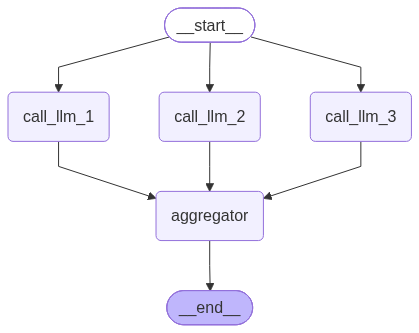

Here's a story, joke, and poem about cats!

STORY:
In the heart of the city, where the cobblestones were worn smooth by a century of footsteps, there was a kingdom. It wasn't a kingdom of people, not really. It was a kingdom of alleys and rooftops, of forgotten gardens and dusty cellars. And its sovereign was a cat named Tiberius.

Tiberius was a ginger tom with fur the color of a sunset and eyes like polished amber. He was not a pet. He was a king. His throne was the warm hood of a forgotten car, his court was the collection of strays who gathered in the alley behind the "Moonlight Diner," and his law was simple: the bold shall eat, the clever shall prosper, and the foolish shall get their tails stepped on.

His chief advisor was a sleek black cat named Midnight, who could melt into shadows and had a purr that could soothe a frantic kitten. His finest hunter was a scarred, grey tabby called Patches, who could leap from a fire escape to a windowsill with the silent grace of a falling l

In [6]:
# Graph state
class State(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    combined_output: str


# Nodes
def call_llm_1(state: State):
    """First LLM call to generate initial joke"""

    msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}


def call_llm_2(state: State):
    """Second LLM call to generate story"""

    msg = llm.invoke(f"Write a story about {state['topic']}")
    return {"story": msg.content}


def call_llm_3(state: State):
    """Third LLM call to generate poem"""

    msg = llm.invoke(f"Write a poem about {state['topic']}")
    return {"poem": msg.content}


def aggregator(state: State):
    """Combine the joke, story and poem into a single output"""

    combined = f"Here's a story, joke, and poem about {state['topic']}!\n\n"
    combined += f"STORY:\n{state['story']}\n\n"
    combined += f"JOKE:\n{state['joke']}\n\n"
    combined += f"POEM:\n{state['poem']}"
    return {"combined_output": combined}


# Build workflow
parallel_builder = StateGraph(State)

# Add nodes
parallel_builder.add_node("call_llm_1", call_llm_1)
parallel_builder.add_node("call_llm_2", call_llm_2)
parallel_builder.add_node("call_llm_3", call_llm_3)
parallel_builder.add_node("aggregator", aggregator)

# Add edges to connect nodes
parallel_builder.add_edge(START, "call_llm_1")
parallel_builder.add_edge(START, "call_llm_2")
parallel_builder.add_edge(START, "call_llm_3")
parallel_builder.add_edge("call_llm_1", "aggregator")
parallel_builder.add_edge("call_llm_2", "aggregator")
parallel_builder.add_edge("call_llm_3", "aggregator")
parallel_builder.add_edge("aggregator", END)
parallel_workflow = parallel_builder.compile()

# Show workflow
display(Image(parallel_workflow.get_graph().draw_mermaid_png()))

# Invoke
state = parallel_workflow.invoke({"topic": "cats"})
print(state["combined_output"])

### Functional API

In [7]:
@task
def call_llm_1(topic: str):
    """First LLM call to generate initial joke"""
    msg = llm.invoke(f"Write a joke about {topic}")
    return msg.content


@task
def call_llm_2(topic: str):
    """Second LLM call to generate story"""
    msg = llm.invoke(f"Write a story about {topic}")
    return msg.content


@task
def call_llm_3(topic):
    """Third LLM call to generate poem"""
    msg = llm.invoke(f"Write a poem about {topic}")
    return msg.content


@task
def aggregator(topic, joke, story, poem):
    """Combine the joke and story into a single output"""

    combined = f"Here's a story, joke, and poem about {topic}!\n\n"
    combined += f"STORY:\n{story}\n\n"
    combined += f"JOKE:\n{joke}\n\n"
    combined += f"POEM:\n{poem}"
    return combined


# Build workflow
@entrypoint()
def parallel_workflow(topic: str):
    joke_fut = call_llm_1(topic)
    story_fut = call_llm_2(topic)
    poem_fut = call_llm_3(topic)
    return aggregator(
        topic, joke_fut.result(), story_fut.result(), poem_fut.result()
    ).result()

# Invoke
stream = parallel_workflow.stream_events("cats", version="v3")
for snapshot in stream.values:
    print(snapshot)
    print("\n")

Here's a story, joke, and poem about cats!

STORY:
[{'type': 'text', 'text': 'In the heart of the city, where the rumble of cars was a constant lullaby and the scent of rain on hot pavement was a daily perfume, lived a cat named Jasper. He was a creature of sleek, midnight-black fur and eyes the color of old gold. To the humans who occasionally spotted him, he was just another stray, a fleeting shadow in an alleyway. But to the other cats of the Quarter, he was a king, a philosopher, and a keeper of secrets.\n\nJasper’s kingdom was a patchwork of territories: the sun-warmed bricks behind the bakery, the cool, damp crawlspace beneath the old theatre, and the cluttered, fragrant jungle of the fish market. His subjects were a motley crew. There was Patches, a calico with a torn ear and the heart of a lioness, who ruled the fish market with a swift paw and a terrifying hiss. There was old Tiberius, a ginger tom so ancient his whiskers were white, who spent his days sleeping on the roof of 

## 路由

路由型 workflow 先处理输入, 再把它们引导到与具体上下文相关的任务上。这样你就能为复杂任务定义专门的流程。例如, 一个用于回答产品相关问题的 workflow 可以先判断问题类型, 再把请求路由到定价、退款、退货等各自的处理流程。

![routing.png](https://docs.langchain.com/oss/images/routing.png)

### Graph API

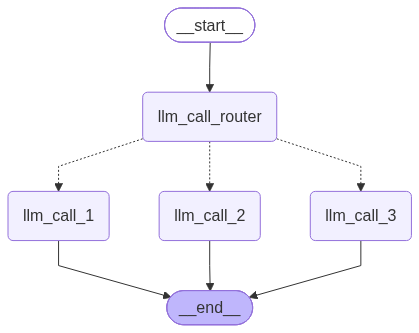

Why did the cat join a band?

Because he wanted to be the **purr**cussionist!


In [8]:
# Schema for structured output to use as routing logic
class Route(BaseModel):
    step: Literal["poem", "story", "joke"] = Field(
        None, description="The next step in the routing process"
    )


# Augment the LLM with schema for structured output
router = llm.with_structured_output(Route)


# State
class State(TypedDict):
    input: str
    decision: str
    output: str


# Nodes
def llm_call_1(state: State):
    """Write a story"""

    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_2(state: State):
    """Write a joke"""

    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_3(state: State):
    """Write a poem"""

    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_router(state: State):
    """Route the input to the appropriate node"""

    # Run the augmented LLM with structured output to serve as routing logic
    decision = router.invoke(
        [
            SystemMessage(
                content="Route the input to story, joke, or poem based on the user's request."
            ),
            HumanMessage(content=state["input"]),
        ]
    )

    return {"decision": decision.step}


# Conditional edge function to route to the appropriate node
def route_decision(state: State):
    # Return the node name you want to visit next
    if state["decision"] == "story":
        return "llm_call_1"
    elif state["decision"] == "joke":
        return "llm_call_2"
    elif state["decision"] == "poem":
        return "llm_call_3"


# Build workflow
router_builder = StateGraph(State)

# Add nodes
router_builder.add_node("llm_call_1", llm_call_1)
router_builder.add_node("llm_call_2", llm_call_2)
router_builder.add_node("llm_call_3", llm_call_3)
router_builder.add_node("llm_call_router", llm_call_router)

# Add edges to connect nodes
router_builder.add_edge(START, "llm_call_router")
router_builder.add_conditional_edges(
    "llm_call_router",
    route_decision,
    {  # Name returned by route_decision : Name of next node to visit
        "llm_call_1": "llm_call_1",
        "llm_call_2": "llm_call_2",
        "llm_call_3": "llm_call_3",
    },
)
router_builder.add_edge("llm_call_1", END)
router_builder.add_edge("llm_call_2", END)
router_builder.add_edge("llm_call_3", END)

# Compile workflow
router_workflow = router_builder.compile()

# Show the workflow
display(Image(router_workflow.get_graph().draw_mermaid_png()))

# Invoke
state = router_workflow.invoke({"input": "Write me a joke about cats"})
print(state["output"])

### Functional API

`Route` schema 与 `router` 已在上文 Graph API 中定义, 此处直接复用。

In [9]:
@task
def llm_call_1(input_: str):
    """Write a story"""
    result = llm.invoke(input_)
    return result.content


@task
def llm_call_2(input_: str):
    """Write a joke"""
    result = llm.invoke(input_)
    return result.content


@task
def llm_call_3(input_: str):
    """Write a poem"""
    result = llm.invoke(input_)
    return result.content


def llm_call_router(input_: str):
    """Route the input to the appropriate node"""
    # Run the augmented LLM with structured output to serve as routing logic
    decision = router.invoke(
        [
            SystemMessage(
                content="Route the input to story, joke, or poem based on the user's request."
            ),
            HumanMessage(content=input_),
        ]
    )
    return decision.step


# Create workflow
@entrypoint()
def router_workflow(input_: str):
    next_step = llm_call_router(input_)
    if next_step == "story":
        llm_call = llm_call_1
    elif next_step == "joke":
        llm_call = llm_call_2
    elif next_step == "poem":
        llm_call = llm_call_3

    return llm_call(input_).result()

# Invoke
stream = router_workflow.stream_events("Write me a joke about cats", version="v3")
for snapshot in stream.values:
    print(snapshot)
    print("\n")

[{'type': 'text', 'text': 'Why did the cat join a band?\n\nBecause he wanted to be the **purr**cussionist!', 'index': 0}]




## Orchestrator-worker

在 orchestrator-worker 配置中, orchestrator 会:

- 把任务拆解成子任务
- 把子任务分派给 workers
- 汇总各 worker 的输出, 形成最终结果

![worker.png](https://docs.langchain.com/oss/images/worker.png)

Orchestrator-worker workflow 灵活性更高, 常用于子任务无法像[并行化](#parallelization)那样预先定义的情况。这在写代码或需要跨多个文件更新内容的 workflow 中很常见。例如, 一个需要在数量未知的文档中更新多个 Python 库安装说明的 workflow, 就可能采用这种模式。

### Graph API

In [10]:
# Schema for structured output to use in planning
class Section(BaseModel):
    name: str = Field(
        description="Name for this section of the report.",
    )
    description: str = Field(
        description="Brief overview of the main topics and concepts to be covered in this section.",
    )


class Sections(BaseModel):
    sections: List[Section] = Field(
        description="Sections of the report.",
    )


# Augment the LLM with schema for structured output
planner = llm.with_structured_output(Sections)

### Functional API

`Section`、`Sections` 与 `planner` 已在上文 Graph API 中定义, 此处直接复用。

In [11]:
@task
def orchestrator(topic: str):
    """Orchestrator that generates a plan for the report"""
    # Generate queries
    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report."),
            HumanMessage(content=f"Here is the report topic: {topic}"),
        ]
    )

    return report_sections.sections


@task
def llm_call(section: Section):
    """Worker writes a section of the report"""

    # Generate section
    result = llm.invoke(
        [
            SystemMessage(content="Write a report section."),
            HumanMessage(
                content=f"Here is the section name: {section.name} and description: {section.description}"
            ),
        ]
    )

    # Write the updated section to completed sections
    return result.content


@task
def synthesizer(completed_sections: list[str]):
    """Synthesize full report from sections"""
    final_report = "\n\n---\n\n".join(completed_sections)
    return final_report


@entrypoint()
def orchestrator_worker(topic: str):
    sections = orchestrator(topic).result()
    section_futures = [llm_call(section) for section in sections]
    final_report = synthesizer(
        [section_fut.result() for section_fut in section_futures]
    ).result()
    return final_report

# Invoke
report = orchestrator_worker.invoke("Create a report on LLM scaling laws")
Markdown(report)

# 1. Introduction: Why Scaling Laws Matter

The modern era of large language models (LLMs) rests on a deceptively simple empirical finding: as models grow larger, train on more data, and consume more compute, their loss decreases in a smooth, predictable fashion. This regularity—the scaling law—has become one of the most consequential discoveries in machine learning, not because it reveals a new algorithm, but because it converts model development from an exercise in trial-and-error into a problem of constrained optimization.

## 1.1 The Empirical Regularity

The core observation is that test loss $L$ on a held-out distribution follows a power law in each of three primary factors: model parameters $N$, dataset size $D$, and training compute $C$. In its simplest form, loss declines as

$$L(N) \propto N^{-\alpha}, \qquad L(D) \propto D^{-\beta}, \qquad L(C) \propto C^{-\gamma},$$

with exponents typically in the range of $0.05$–$0.1$ for compute and somewhat larger for data and parameters in the regimes studied to date. These relationships hold across several orders of magnitude—from models with millions of parameters to those with hundreds of billions—and appear robust to architectural details, provided the model family is held fixed. The practical implication is striking: performance on a target task can be forecast *before* a training run is launched, using only small-scale experiments and a fitted curve.

## 1.2 Historical Arc: From Kaplan to Chinchilla to Modern Practice

The systematic study of these laws begins with **Kaplan et al. (2020)**, who trained a series of transformer language models and found that loss scales as a power law in $N$, $D$, and $C$ separately, with the notable conclusion that model size should be prioritized over data when compute is fixed. Their prescription—"bigger models, fewer tokens"—shaped the first generation of frontier LLMs, including GPT-3.

This consensus was overturned by **Hoffmann et al. (2022)**, the *Chinchilla* paper, which showed that Kaplan et al.'s exponents were distorted by learning-rate schedules that had not been tuned for the smaller-data regime. Under a corrected methodology, the compute-optimal allocation was approximately *equal* scaling: for a fixed compute budget, parameters and training tokens should grow in roughly equal proportion. Chinchilla's 70B model, trained on 1.4T tokens, outperformed the 280B Gopher model trained on far fewer tokens—a result that immediately reoriented industry practice toward data-rich training.

**Modern practice** has since moved beyond strict compute-optimality. Frontier labs deliberately train *over-parameterized* models well past the Chinchilla point, because inference cost, not training cost, dominates lifetime expenditure: a smaller model that is cheaper to serve justifies a larger training budget. This "inference-aware" scaling, together with the discovery of emergent capabilities at scale and the rise of mixture-of-experts architectures, has made scaling laws a design tool rather than a single prescription.

## 1.3 Why Predictability Matters

The value of scaling laws lies in their *predictive* character. Because loss is a smooth function of scale, a lab can:

- **Allocate resources principledly.** Given a fixed compute or dollar budget, scaling laws specify the optimal split between parameters, data, and training time—turning a multi-million-dollar decision into a curve-fitting exercise.
- **Forecast capability.** Downstream benchmark performance often correlates with loss, so extrapolated loss curves provide early signals about whether a planned run will reach a target capability threshold.
- **Compare architectures fairly.** By controlling for scale, scaling laws isolate the effect of architectural or algorithmic changes from the confound of raw size.
- **Plan infrastructure.** Predictable compute requirements inform hardware procurement, data pipeline design, and training-schedule choices months in advance.

## 1.4 The Central Tension: Scaling versus Efficiency

Yet scaling laws also expose a fundamental tension. If loss falls as a power law, then each additional order of magnitude of compute yields a diminishing—but reliable—return. The question is no longer *whether* to scale, but *how far* scaling remains worthwhile relative to algorithmic efficiency. A 2× improvement in data efficiency, for instance, is equivalent to a 2× increase in compute—often far cheaper to obtain. This has driven interest in better data curation, architectural innovations, and training recipes that shift the scaling curve itself rather than merely moving along it.

The remainder of this report examines the empirical foundations of these laws, the methodological debates that produced the Kaplan–Chinchilla reversal, the extensions to inference and emergent behavior, and the open question of whether power-law scaling can continue indefinitely or will eventually encounter hard limits in data, compute, or architecture.

---

# Foundations: Power Laws and the Three Axes of Scale

## The Scaling Relationship

The empirical study of neural scaling laws begins with a deceptively simple premise: the loss achieved by a language model is a predictable function of the resources invested in training it. Formally, we write this relationship as

$$L(N, D, C)$$

where $L$ denotes the test loss (typically cross-entropy on held-out data), $N$ is the number of trainable parameters in the model, $D$ is the number of training tokens, and $C$ is the compute budget expended. These three quantities are not independent. For a dense transformer, compute is approximately

$$C \approx 6ND$$

where the factor of 6 accounts for the forward and backward passes over each parameter and token (Kaplan et al., 2020). This constraint means that any two of the three axes determine the third, and it is precisely this coupling that makes the scaling problem interesting: given a fixed compute budget, how should one allocate it between a larger model and more data?

## Power-Law Behavior and Irreducible Loss

The central empirical finding is that loss decreases as a power law in each of the relevant quantities, once other factors are held fixed. A canonical parameterization (Hoffmann et al., 2022) takes the form

$$L(N, D) = \frac{A}{N^\alpha} + \frac{B}{D^\beta} + L_\infty$$

where $A$, $B$, $\alpha$, and $\beta$ are fitted constants, and $L_\infty$ is the **irreducible loss**—the entropy floor of natural language that no amount of scaling can eliminate. The exponents $\alpha$ and $\beta$ are typically small (on the order of 0.05–0.1 for parameter count and 0.1–0.3 for data), which is why improvements require orders-of-magnitude increases in scale.

The additive structure of this equation carries an important implication: the two terms represent independent bottlenecks. A model with too few parameters cannot represent the required function, regardless of how much data it sees; a model trained on too few tokens cannot learn the distribution, regardless of how large it is. The loss is dominated by whichever term is larger, and the optimal allocation balances them.

## Why Log-Log Linearity Emerges

The power-law form is not an accident of curve fitting. It arises from the geometry of high-dimensional function approximation. In a $d$-dimensional input space, the number of parameters needed to approximate a function to error $\epsilon$ scales as $\epsilon^{-d/k}$ for a function with $k$ bounded derivatives, which translates to a loss that decays as a power law in $N$. Similar arguments apply to the data term: the number of samples required to estimate a distribution to a given accuracy scales polynomially with the accuracy, yielding a power law in $D$. When plotted on log-log axes, these relationships appear as straight lines, and the slopes correspond to the exponents $\alpha$ and $\beta$. The linearity is thus a signature of the underlying approximation-theoretic structure, not merely a convenient visualization.

## Compute-Optimal vs. Training-Optimal

The distinction between **compute-optimal** and **training-optimal** regimes is central to practical scaling decisions. A training run is *compute-optimal* if, for a fixed compute budget $C$, it minimizes loss—that is, it sits on the frontier of the best achievable loss for that budget. A run is *training-optimal* in a looser sense if it achieves the best loss given the model size and data available, without regard to whether those resources were the best use of compute.

The influential result of Hoffmann et al. (2022) is that compute-optimal training requires scaling $N$ and $D$ in roughly equal proportion: as compute increases, both the model and the dataset should grow, with $D \approx 20N$ as a rule of thumb. This corrected an earlier prescription (Kaplan et al., 2020) that favored much larger models trained on comparatively less data. The practical consequence is that many models in the wild are *over-parameterized* relative to their data—they are training-optimal for their size but not compute-optimal for the budget that produced them.

## IsoFLOP Curves

The tool for visualizing this trade-off is the **isoFLOP curve**. For a fixed compute budget $C$, the constraint $C \approx 6ND$ defines a hyperbola in the $(N, D)$ plane. Along this curve, one can train models of varying size and measure the resulting loss. The curve of loss versus $N$ (with $D = C/(6N)$) typically has a U-shape: very small models underfit because they lack capacity, while very large models underfit because they are starved of data. The minimum of this U identifies the compute-optimal model size for that budget. Plotting the minima across many budgets traces out the compute-optimal frontier, and fitting a power law to these minima yields the scaling exponents that govern optimal allocation.

## Loss vs. Downstream Performance

A crucial caveat is that **loss and downstream task performance are not the same thing**. Cross-entropy loss is a smooth, well-behaved proxy that follows clean power laws, but downstream metrics—accuracy on reasoning benchmarks, pass rates on code generation, factuality in question answering—often exhibit different behavior. Some capabilities appear to emerge abruptly at certain scales, a phenomenon sometimes called *emergence*, though recent work suggests that apparent discontinuities can be artifacts of the metric chosen (Schaeffer et al., 2023). In general, improvements in loss translate to improvements in downstream performance, but the mapping is nonlinear and task-dependent. A model that is compute-optimal by loss may not be optimal for a specific application, and practitioners should treat loss scaling as a guide rather than a guarantee.

## Key Terminology Summary

- **$L(N, D, C)$**: the loss as a function of parameters, tokens, and compute.
- **Power law**: $L \propto N^{-\alpha}$ or $D^{-\beta}$, appearing linear on log-log axes.
- **Irreducible loss ($L_\infty$)**: the entropy floor of the data distribution.
- **Compute-optimal**: minimizing loss for a fixed compute budget.
- **Training-optimal**: achieving the best loss for a given model and dataset, regardless of budget efficiency.
- **IsoFLOP curve**: the locus of $(N, D)$ pairs at constant compute, used to find optimal allocations.
- **Loss vs. downstream performance**: the distinction between the smooth proxy and the task-specific metrics that ultimately matter.

---

# The Kaplan Era: Early Scaling Laws

## The 2020 Scaling Laws Paper

In January 2020, Jared Kaplan, Sam McCandlish, Tom Henighan, Tom Brown, Benjamin Chess, Rewon Child, Scott Gray, Alec Radford, Jeffrey Wu, and Dario Amodei published "Scaling Laws for Neural Language Models," a work that fundamentally reshaped how the field thought about building large language models. At the time, the largest models in existence—GPT-2 at 1.5 billion parameters—were still modest by later standards, and the field lacked a principled framework for deciding how to allocate compute. The Kaplan paper provided exactly that: a set of empirical power laws relating model performance to three variables—model size (parameters, $N$), dataset size (tokens, $D$), and compute budget ($C$)—that held with remarkable consistency across more than two orders of magnitude.

The central finding was that cross-entropy loss $L$ follows a power law in each of these variables when the others are not bottlenecks:

$$L(N) = \left(\frac{N_c}{N}\right)^{\alpha_N}, \quad L(D) = \left(\frac{D_c}{D}\right)^{\alpha_D}, \quad L(C) = \left(\frac{C_c}{C}\right)^{\alpha_C}$$

The fitted exponents were approximately $\alpha_N \approx 0.076$, $\alpha_D \approx 0.095$, and $\alpha_C \approx 0.050$. These are small numbers—loss improves slowly—but the exponents are stable, and the implications compound dramatically over the scales that would soon become relevant. The paper also identified a joint dependence: when both $N$ and $D$ are constrained, performance is limited by whichever is the tighter bottleneck, and the authors proposed a combined functional form that interpolates between the two regimes.

## The Prioritization of Model Size

Perhaps the most consequential claim in the Kaplan paper was that, under a fixed compute budget, it is better to invest in a larger model and train it on fewer tokens than to train a smaller model on more data. The authors derived this from their fitted exponents: because $\alpha_N > \alpha_C$ in the relevant regime, and because the compute cost scales roughly linearly with $N \cdot D$, the optimal allocation under a fixed FLOP budget was to scale $N$ aggressively while scaling $D$ only modestly.

Specifically, the paper argued that the optimal model size should scale as $N \propto C^{0.73}$ and the optimal number of training tokens as $D \propto C^{0.27}$. In other words, when you increase your compute budget by 10×, you should increase model size by roughly 5.4× and data by only about 1.9×. This was a striking conclusion: it suggested that the field's instinct to gather ever-larger datasets was less important than building ever-larger models.

The paper also noted that large models are more sample-efficient—they reach a given loss with fewer tokens than smaller models—which reinforced the case for prioritizing parameters. This finding directly influenced the design of GPT-3, which used 175 billion parameters trained on roughly 300 billion tokens, a ratio that reflected the Kaplan-optimal allocation rather than a data-heavy approach.

## The 6ND Compute Approximation

The Kaplan paper also popularized a simple heuristic for estimating training compute: $C \approx 6ND$, where $N$ is the number of parameters and $D$ is the number of training tokens. The derivation is straightforward. For a dense transformer, the forward pass requires approximately $2ND$ FLOPs (each parameter participates in roughly two multiply-accumulate operations per token: one in the attention projections and one in the MLP). The backward pass requires approximately twice the forward pass, giving $4ND$. Summing forward and backward yields $6ND$.

This approximation became ubiquitous in the field. It allowed researchers to compare training runs, estimate compute budgets, and reason about scaling without detailed profiling. It also became the basis for compute-optimal scaling analyses, including the later Chinchilla work. The $6ND$ formula is not exact—it ignores attention's quadratic term, embedding costs, and various overheads—but for models where $N$ is large and sequence lengths are moderate, it is accurate to within a small factor, and its simplicity made it indispensable.

## Methodology and Its Influence

The Kaplan methodology was empirical and inductive. The authors trained models across a grid of sizes (from roughly 10 million to 1.5 billion parameters) and dataset sizes, measured final loss, and fit power laws. They were careful to control for learning rate schedules, batch sizes, and other hyperparameters, and they showed that the laws held across architectures (transformers and LSTMs) and optimizers. The result was a predictive framework: given a compute budget, one could forecast the loss of a model before training it.

The influence on GPT-3-era design was direct and substantial. GPT-3's architecture and training regime were shaped by Kaplan's recommendations: a very large model, a relatively modest token count by later standards, and a compute budget allocated according to the $N \propto C^{0.73}$ rule. Other labs followed suit. The paper also shifted the field's culture: scaling was no longer a matter of intuition but of quantitative prediction, and "scaling laws" became a standard part of the language model development toolkit.

## Assumptions That Later Proved Problematic

The Kaplan laws were not wrong, but their assumptions were narrower than they appeared. Three issues became apparent in subsequent years.

First, the laws were fit in a regime where models were undertrained relative to their size. The datasets used in the Kaplan experiments were often smaller than what the models could have absorbed, which meant the fitted exponents reflected a data-limited regime. When later work (notably Hoffmann et al., 2022, the "Chinchilla" paper) trained models on far more tokens, the optimal allocation shifted: for a fixed compute budget, one should scale data and model size roughly equally, not prioritize model size. The Chinchilla exponents implied $N \propto C^{0.5}$ and $D \propto C^{0.5}$, a direct challenge to Kaplan's $0.73/0.27$ split.

Second, the Kaplan laws assumed a fixed learning rate schedule and did not account for the possibility that training beyond a certain point yields diminishing returns due to optimization difficulties rather than data limitations. Later work showed that with appropriate schedules, models could be trained on far more tokens than Kaplan's grid suggested, and that the loss continued to improve.

Third, the $6ND$ approximation, while useful, ignores the quadratic attention cost that becomes significant at long sequence lengths. As context windows grew from 1,024 to 32,000 tokens and beyond, the approximation became less accurate, and compute estimates required correction.

The Kaplan era thus represents both a breakthrough and a cautionary tale. It demonstrated that scaling could be predicted and optimized, but it also showed that empirical laws are only as good as the regime in which they are measured. The transition to Chinchilla-style scaling was not a refutation of Kaplan's method but a correction of its scope—a reminder that in a rapidly scaling field, the boundaries of the data are as important as the laws themselves.

---

# Chinchilla and the Compute-Optimal Correction

## Background: The Kaplan Scaling Laws and Their Prescription

The modern practice of scaling large language models rests on a lineage of empirical scaling laws initiated by Kaplan et al. (2020), who fit power-law relationships between model loss and three factors: model size (parameters, $N$), dataset size (tokens, $D$), and compute ($C$). Their central finding was that loss depends strongly on $N$ and only weakly on $D$ within the ranges studied, implying that—for a fixed compute budget—one should train very large models on comparatively little data and stop well before convergence. Under this prescription, compute-optimal training allocated the vast majority of additional compute to parameters rather than tokens, yielding a rule of thumb that model size should grow roughly an order of magnitude faster than data. This guidance directly shaped the design of the GPT-3-class generation of models: hundreds of billions of parameters trained on a few hundred billion tokens, with training often halted before the loss curve had flattened.

## The Chinchilla Study: Three Independent Estimation Approaches

Hoffmann et al. (2022), working at DeepMind, revisited the compute-optimal frontier with a substantially larger and more carefully controlled experimental program, training over 400 models ranging from 70M to 16B parameters and 5B to 500B tokens. Rather than relying on a single fitting procedure, they estimated the optimal allocation of compute between $N$ and $D$ using three methodologically independent approaches:

1. **Minimum-over-training-runs**: For each fixed compute budget, train models of several sizes to convergence and record the minimum achievable loss, then fit the compute-optimal frontier through these minima.
2. **IsoFLOP profiles**: Hold compute constant across a family of runs, sweep model size, and fit a parabola to loss as a function of $\log N$ to locate the minimum and its corresponding token count.
3. **Parametric loss modeling**: Fit a functional form $L(N, D) = E + A/N^{\alpha} + B/D^{\beta}$ to the full set of runs, then analytically minimize loss subject to the constraint $C \approx 6ND$.

All three approaches converged on the same qualitative conclusion, which lent the result unusual robustness by the standards of scaling-law work.

## The Revised ~20 Tokens per Parameter Rule

The headline result was that compute-optimal training requires model size and dataset size to scale in roughly equal proportion: when compute increases by $8\times$, both $N$ and $D$ should approximately double. This yields the now-canonical heuristic that a model should be trained on approximately **20 tokens per parameter**. The parametric fit gave exponents of roughly $\alpha \approx 0.34$ and $\beta \approx 0.28$ in the loss model above, implying $N_{opt} \propto C^{0.50}$ and $D_{opt} \propto C^{0.50}$—in sharp contrast to the Kaplan-era exponents, which implied $N_{opt} \propto C^{0.73}$ and $D_{opt} \propto C^{0.27}$.

The practical implication was stark: **most large models of the preceding era were significantly undertrained**. GPT-3 (175B parameters, ~300B tokens) sat at under 2 tokens per parameter, roughly an order of magnitude below the Chinchilla-optimal ratio. Chinchilla itself—70B parameters trained on 1.4T tokens—outperformed models several times its size (including Gopher at 280B and GPT-3 at 175B) on a wide range of benchmarks, at substantially lower inference cost.

## Reconciling Kaplan and Chinchilla: Methodological Sources of the Discrepancy

The contradiction between the two studies prompted a careful post-hoc analysis, most notably by the authors of the Chinchilla paper themselves and in subsequent commentary. Three methodological factors account for most of the gap:

- **Learning rate schedules.** Kaplan et al. typically used a fixed learning rate schedule tuned for each model size, and—critically—compared models at a fixed *token count* rather than at convergence. Because larger models descend the loss curve faster early in training, this protocol systematically favored large models and made data appear less valuable than it is. Chinchilla used cosine decay schedules with a warmup, tuned per run, and evaluated models at or near convergence, which allows the benefit of additional data to fully materialize.
- **Cosine decay and the treatment of the final loss.** The choice of cosine decay to a low terminal learning rate materially improves final loss, and the improvement is larger for smaller models trained on more data. Failing to use such a schedule—or comparing intermediate checkpoints—distorts the inferred $N$–$D$ trade-off.
- **Data contamination and evaluation artifacts.** Some of the apparent advantage of large models in the Kaplan regime may have been inflated by benchmark contamination or by evaluation on distributions that favored memorization over generalization. Chinchilla's cleaner evaluation and the use of held-out perplexity as the primary fitting target reduced this confound.

In short, the Kaplan exponents were not "wrong" as a description of the specific training protocol studied; they were an artifact of that protocol. Once learning rate schedules were properly tuned and models were compared at convergence, the data exponent rose and the parameter exponent fell, producing the near-equal scaling of Chinchilla.

## Practical Consequences and the "Chinchilla-Optimal" Era

The Chinchilla correction reshaped model design almost immediately:

- **Reallocation of compute toward data.** Frontier labs shifted from "biggest model wins" to "best-trained model wins," dramatically increasing token budgets. LLaMA (2023) trained 7B–65B models on 1–1.4T tokens, far beyond the Chinchilla ratio, and demonstrated that smaller, well-trained models could match or exceed much larger undertrained ones.
- **Inference-cost awareness.** Because inference cost scales with $N$ but not $D$, Chinchilla-optimal (or beyond-optimal) training is economically attractive: a smaller model trained longer is cheaper to serve at equal quality. This reframed scaling as an end-to-end optimization problem rather than a training-only one.
- **The "over-training" regime.** Subsequent work (e.g., LLaMA, and analyses by Touvron et al. and others) showed that for models intended for heavy inference use, it is often optimal to train well *past* the Chinchilla point—sometimes 100+ tokens per parameter—because the marginal inference savings outweigh the extra training compute. The Chinchilla rule thus became a baseline rather than a ceiling.
- **Data as the binding constraint.** The correction exposed a looming bottleneck: if compute-optimal training demands ~20 tokens per parameter, then trillion-parameter models would require tens of trillions of high-quality tokens, far exceeding the supply of curated web text. This realization fueled intense interest in data curation, synthetic data, deduplication, and multi-epoch training, and it reframed data quality and quantity as first-class scaling variables.

The Chinchilla result did not merely adjust a constant; it reoriented the field's default assumptions about how to spend compute, and it established the empirical foundation on which nearly all subsequent open and frontier model training decisions have been made.

---

# Beyond Chinchilla: Inference-Aware and Over-Training Regimes

## From Training-Optimal to Deployment-Optimal Scaling

The Chinchilla scaling laws established a clear prescription for compute-optimal training: for a fixed training compute budget $C$, model parameters $N$ and training tokens $D$ should be scaled roughly in proportion, with $N \propto C^{0.5}$ and $D \propto C^{0.5}$ (Hoffmann et al., 2022). This framework answered the question of how to *train* the best model for a given budget. It did not, however, answer the question that actually dominates real-world economics: how to *deploy* the best model for a given total cost of ownership.

The distinction matters because training is a one-time capital expenditure, while inference is a recurring operational cost. A model that is training-optimal may be inference-suboptimal—too large, too slow, and too expensive to serve at scale. As LLMs moved from research artifacts to production systems serving billions of requests, the field underwent a decisive shift from training-optimal to deployment-optimal scaling. This section examines that shift: the rise of Llama-style over-training, the development of inference-aware scaling laws, and the trade-off between training FLOPs and serving FLOPs that now governs frontier model design.

## The Economics of Over-Training

The core insight behind over-training is simple: if a model will be served many times, it is worth spending extra training compute to reduce its inference cost. Training a smaller model on far more tokens than Chinchilla would recommend produces a model that is cheaper to run at every subsequent inference call. The one-time training overhead is amortized across the entire serving lifetime.

This is precisely the strategy behind the Llama family. Llama 1 (Touvron et al., 2023a) was trained on 1.0–1.4 trillion tokens, already exceeding Chinchilla-optimal token counts for its parameter sizes. Llama 2 (Touvron et al., 2023b) pushed further, training 7B–70B models on 2 trillion tokens. Llama 3 (Meta, 2024) dramatically extended this trend: the 8B model was trained on approximately 15 trillion tokens—roughly 1,875 tokens per parameter, compared to Chinchilla's recommended ~20. The 70B model was trained on the same 15T token corpus, yielding ~214 tokens per parameter. Both are far beyond compute-optimal, and both are deliberately so.

The rationale is quantifiable. Consider a model with $N$ parameters trained on $D$ tokens, with training FLOPs $C_{\text{train}} \approx 6ND$ and inference FLOPs per token $C_{\text{inf}} \approx 2N$. If the model serves $Q$ tokens over its lifetime, total cost is:

$$C_{\text{total}} = 6ND + 2NQ = N(6D + 2Q)$$

For a fixed total budget, the optimal $N$ decreases as $Q$ grows. When $Q \gg D$—as is typical for widely deployed models—the inference term dominates, and the optimal strategy shifts toward smaller $N$ and larger $D$. This is the mathematical foundation of over-training.

## Inference-Aware Scaling Laws

Classical scaling laws optimize for training loss given training compute. Inference-aware scaling laws instead optimize for a joint objective: minimize loss subject to a constraint on total compute (training + inference), or minimize total cost subject to a target loss.

Sardana et al. (2023) formalized this by introducing an inference cost term into the scaling law framework. Their key result is that the optimal model size depends on the inference-to-training compute ratio. Let $R = Q/D$ be the ratio of inference tokens to training tokens. Then the optimal $N$ scales as:

$$N^* \propto C_{\text{total}}^{0.5} \cdot f(R)$$

where $f(R)$ decreases as $R$ increases. In the limit of very large $R$ (heavy serving), the optimal model becomes much smaller than Chinchilla would suggest, and the optimal $D$ becomes much larger.

This reframes the scaling question entirely. The "optimal" model is no longer a fixed point determined by training compute alone; it is a function of the deployment context. A model serving 10 billion tokens per day has a very different optimal size than a model serving 10 million tokens per day, even if both were trained with the same budget.

## The Training FLOPs vs. Serving FLOPs Trade-off

The trade-off can be visualized as a Pareto frontier. For a given total compute budget $C_{\text{total}} = C_{\text{train}} + C_{\text{serve}}$, there is a family of $(N, D)$ pairs that achieve the same loss. The training-optimal point minimizes $C_{\text{train}}$ for a target loss; the deployment-optimal point minimizes $C_{\text{total}}$ for that loss.

Three regimes emerge:

1. **Training-dominated** ($Q \ll D$): Chinchilla-optimal scaling is approximately correct. This applies to research models, one-off fine-tunes, or models with very limited deployment.

2. **Balanced** ($Q \sim D$): The optimal model is moderately smaller than Chinchilla-optimal, with moderately more training tokens. This is the regime of many enterprise deployments.

3. **Inference-dominated** ($Q \gg D$): The optimal model is substantially smaller and trained on far more tokens. This is the regime of consumer-facing LLM products, API services, and edge deployments.

The Llama 3 8B model sits firmly in regime 3. Its training cost is high—roughly $6 \times 8 \times 10^9 \times 15 \times 10^{12} \approx 7.2 \times 10^{23}$ FLOPs—but its inference cost is low enough that serving even a few billion tokens recovers the training investment relative to a larger, Chinchilla-optimal alternative.

## Total Cost of Ownership and Optimal N/D Ratios

Total cost of ownership (TCO) for an LLM deployment includes training compute, inference compute, memory footprint, latency constraints, and hardware utilization. Each factor pushes the optimal $N/D$ ratio in a specific direction:

- **Inference compute** pushes $N$ down and $D$ up.
- **Memory footprint** (model weights must fit in GPU memory) pushes $N$ down.
- **Latency constraints** (tokens per second) push $N$ down.
- **Training compute budget** pushes $N$ up (larger models are more sample-efficient).
- **Data availability** caps $D$; beyond a certain point, additional tokens yield diminishing returns or require synthetic data.

The net effect is that modern frontier models are trained at $N/D$ ratios far below Chinchilla's ~1:20. Llama 3 8B is at ~1:1,875. Mistral 7B (Jiang et al., 2023) is similarly over-trained. Even larger models like Llama 3 70B (~1:214) and DeepSeek-V2 (DeepSeek-AI, 2024) show the same trend. The industry has converged on the view that for any model intended for serious deployment, over-training is not a compromise—it is the correct optimization.

## Small-but-Heavily-Trained Models

The most visible consequence of this shift is the emergence of small-but-heavily-trained models: models in the 1B–10B parameter range trained on trillions of tokens. These models are not "small" in the traditional sense; they are small in parameter count but large in training investment.

Examples include:

- **Llama 3 8B**: 8B parameters, 15T tokens.
- **Phi-3 (Microsoft, 2024)**: 3.8B parameters, 3.3T tokens, with a strong emphasis on data quality.
- **Gemma 2 (Google, 2024)**: 2B and 9B variants trained on 2T–8T tokens.
- **Qwen 2.5 (Alibaba, 2024)**: 0.5B–72B variants, with smaller models trained on up to 18T tokens.

These models achieve performance comparable to much larger Chinchilla-optimal models while being dramatically cheaper to serve. The Phi-3 technical report explicitly frames this as a data-quality and over-training strategy: by curating a smaller, higher-quality dataset and training far beyond compute-optimal, the model achieves strong performance at a fraction of the inference cost.

The small-but-heavily-trained paradigm also enables new deployment scenarios: on-device inference, edge computing, and high-throughput API services where per-token cost is the binding constraint. It has effectively decoupled model capability from model size, at least within the range where data quality and training duration can compensate for parameter count.

## Implications and Open Questions

The shift beyond Chinchilla has several implications:

1. **Scaling laws must be deployment-aware.** Training-optimal scaling laws are a special case of a more general framework that includes inference cost. Future scaling research should report optimal $N$ and $D$ as functions of the expected inference load.

2. **Data quality becomes the binding constraint.** When $D$ is pushed to trillions of tokens, the marginal value of additional data depends heavily on its quality. This has driven investment in data curation, synthetic data generation, and curriculum learning.

3. **The optimal N/D ratio is not universal.** It depends on the deployment context. A model for a low-traffic internal tool should be trained closer to Chinchilla-optimal; a model for a high-traffic consumer product should be heavily over-trained.

4. **Diminishing returns to over-training.** There is a limit to how far over-training can compensate for parameter count. At some point, the loss curve flattens, and further training tokens yield little improvement. The exact shape of this curve—and where the limit lies—remains an open empirical question.

5. **Inference-time compute changes the calculus.** Techniques like chain-of-thought reasoning, speculative decoding, and test-time scaling add inference cost that is not captured by the simple $2N$ per-token estimate. As inference-time compute becomes a larger share of total cost, the optimal model size may shift again.

The field has moved decisively past the Chinchilla prescription. The new default is inference-aware, deployment-optimal scaling—and the models that result look very different from what training-optimal scaling would have produced.

---

# Emergent Abilities and the Metrics Debate

## The Emergence Claim

The modern scaling literature has repeatedly reported that certain capabilities appear to switch on abruptly as model size, data, or compute increase. In the framing popularized by Wei et al. (2022), an ability is "emergent" if it is "not present in smaller models but is present in larger models" — and, critically, if its appearance is sharp rather than gradual. Canonical examples include multi-step arithmetic, chain-of-thought reasoning, instruction following, and certain symbolic manipulation tasks, all of which were reported to hover near chance for many orders of magnitude of scale before jumping to strong performance over a comparatively narrow range.

This claim carries substantial weight for how the field reasons about progress. If capabilities genuinely emerge discontinuously, then (i) scaling laws fit to smooth metrics like loss would be poor predictors of downstream competence, (ii) safety-relevant behaviors might appear suddenly in future models without warning, and (iii) evaluation at a single scale could badly mislead about a model's trajectory. Emergence thus became both a scientific puzzle and a governance concern.

## The Metric Artifact Counterargument

Schaeffer et al. (2023) challenged the phenomenon directly, arguing that "emergent abilities" are largely a mirage created by the choice of metric. Their core observation is that a capability is only ever measured through some scoring function, and many standard metrics are **discontinuous** with respect to the underlying per-token or per-example competence. Multiple-choice accuracy, exact-match string matching, and all-or-nothing task success are step functions: a model that improves its probability of producing the correct answer from 5% to 40% still scores near zero on exact match, then appears to "jump" as it crosses the threshold where most samples become correct.

When the same model outputs are re-scored with **smooth, continuous metrics** — token-level log-likelihood, edit distance, or the probability assigned to the correct answer — the apparent discontinuities flatten into smooth, predictable curves. Schaeffer et al. demonstrated this across several purported emergence cases, showing that the sharp transitions in the original papers dissolve under metric substitution. Their conclusion is deflationary: the underlying capability improves gradually and predictably with scale; only its *measurement* is abrupt.

## Smooth vs. Sharp Transitions and Benchmark Choice

The debate turns on a distinction that is easy to conflate: discontinuity in the *model* versus discontinuity in the *metric*. Three positions are defensible:

1. **Pure artifact.** All reported emergence is a metric effect; the underlying competence is smooth. This is the strong Schaeffer reading.
2. **Genuine emergence.** Some capabilities reflect real phase-transition-like changes in what the network computes, not merely how we score it.
3. **Mixed.** Most cases are metric artifacts, but a subset reflect real nonlinearities in the loss landscape or in the composition of sub-skills.

Benchmark choice is decisive here. Tasks requiring exact multi-step outputs (e.g., GSM8K final-answer accuracy) are maximally susceptible to threshold effects, because a single wrong token zeroes the score. Tasks scored by partial credit, perplexity, or calibrated probability are far less so. This means the *same* model can appear to exhibit emergence or smooth improvement depending entirely on the evaluation harness — a point with direct methodological consequences: claims of emergence should be accompanied by a demonstration that the discontinuity survives metric changes, not merely that it appears under one scoring rule.

## Implications for Predicting Capability from Loss

If emergence is largely a metric artifact, the practical picture becomes more tractable. Smooth metrics such as validation loss are, under this view, informative about downstream capability after all — the mapping from loss to competence is monotonic and gradual, and apparent jumps are threshold crossings in a discontinuous scorer. This restores some confidence in using loss curves for forecasting: a model's probability of satisfying a hard criterion can be estimated from its smooth per-example performance, and the "emergence point" is simply where that probability crosses the scoring threshold.

The caveat is that this only holds when the capability decomposes into independently improving sub-skills whose aggregate probability rises smoothly. If a task requires *simultaneously* mastering several sub-skills, the aggregate can still rise sharply even under smooth per-skill curves — a genuine compositional nonlinearity rather than a pure measurement artifact. Distinguishing these cases requires probing intermediate quantities (per-token accuracy, partial-credit scores) rather than relying on end-task accuracy alone.

## Grokking and Phase Transitions in Training

A related but distinct phenomenon is **grokking** (Power et al., 2022): networks trained on algorithmic tasks such as modular arithmetic can memorize the training set quickly while generalizing only after many additional epochs, with test accuracy jumping from chance to near-perfect long after training loss has flattened. Unlike the scaling debate, grokking is a transition in *training time* rather than model scale, and it is harder to dismiss as a metric artifact because the jump is visible in the same continuous metric (test accuracy) that was flat beforehand.

Grokking is often interpreted through the lens of phase transitions and competing internal circuits: a memorizing solution is learned first, then a generalizing solution emerges and eventually dominates, with the transition sharpened by weight decay and dataset structure. Related work on **emergent abilities as phase transitions** (e.g., in in-context learning and induction-head formation) suggests that some nonlinearities are properties of the optimization dynamics and internal representations, not of the scorer. This provides the strongest counterweight to the pure-artifact view: even if many benchmark discontinuities are metric-induced, there exist genuine sharp transitions in what models learn and when.

## Synthesis

The metrics debate has productively reframed the emergence question. The defensible consensus is:

- **Many** reported emergent abilities are artifacts of discontinuous metrics; under smooth scoring they become gradual and predictable.
- **Some** nonlinearities are real, arising from compositional task structure, phase transitions in training dynamics (grokking), or the formation of specific circuits.
- **Benchmark and metric choice** therefore determine whether emergence is observed, making evaluation design a first-class scientific variable rather than a neutral instrument.
- **For forecasting**, smooth metrics like loss retain predictive value for threshold-crossing behavior, but predictions of *hard* capabilities require modeling how sub-skills compose and when internal circuits form — not just extrapolating loss.

The practical upshot is that "emergence" should be treated as a claim requiring evidence: a discontinuity that persists across metrics, tasks, and seeds, and that can be traced to a mechanism (composition, phase transition, circuit formation) rather than to a scoring threshold. Absent that evidence, the parsimonious explanation remains smooth capability growth measured through a discontinuous lens.

---

# Data Scaling, Quality, and the Data Wall

## 1. From Parameter Scaling to Data Scaling

The first generation of neural scaling laws treated dataset size as a secondary axis: models were scaled until compute or parameters became the bottleneck, and data was assumed to be abundant enough to feed them. This assumption no longer holds. Chinchilla-style analyses established that, for a fixed compute budget, loss is minimized when parameters and training tokens are scaled in roughly proportional fashion, with the compute-optimal token count growing faster than the parameter count. The practical consequence is that frontier training runs now demand trillions of tokens—an order of magnitude more than the parameter-centric era assumed—and the supply of suitable text has become a first-class constraint rather than a background condition.

## 2. Data Quality as a Scaling Variable

The most important refinement of the scaling picture is that *quantity* and *quality* are not separable. Loss curves are not a function of raw token count but of the effective distribution of tokens: how much redundancy, boilerplate, toxicity, and near-duplicate content they contain, and how well they match the target distribution.

**Deduplication.** Web-scale corpora contain enormous redundancy—mirrored pages, syndicated articles, boilerplate headers, and near-identical documents. Deduplication at the document and substring level consistently improves loss at fixed token budget, and the effect is large enough to rival substantial increases in dataset size. Near-duplicate removal is especially consequential because repeated exposure to identical sequences encourages memorization rather than generalization, degrading both held-out loss and downstream robustness.

**Filtering.** Quality classifiers, perplexity-based filters, and heuristic rules (length, symbol ratio, language identification) reshape the training distribution toward fluent, information-dense text. Aggressive filtering improves loss per token but reduces yield, so the two effects trade off: the optimal filter threshold is an empirical question, and it shifts as the model scale changes. Notably, quality filtering disproportionately removes text from underrepresented domains and languages, which can harm coverage even as it improves average loss.

**The quality–quantity frontier.** Because filtering and deduplication reduce the usable token count, they effectively move the model along the data axis of the scaling law. The practical framing is a frontier: for a given compute budget, one chooses a (filtered) dataset size and quality level jointly. Improvements in filtering are therefore equivalent to *shifting the loss curve downward* at fixed tokens—a form of scaling that does not require new data.

## 3. Repetition and Multi-Epoch Training

When unique high-quality tokens run short, the natural response is to train for multiple epochs. The evidence here is consistent and sobering:

- **Diminishing returns.** The first epoch contributes the most; each subsequent epoch yields progressively smaller loss reductions. Empirically, the value of the *n*-th epoch decays roughly as a power law, so that a small number of epochs (typically up to ~4) captures most of the benefit, after which returns flatten sharply.
- **Repetition is not free.** Beyond a modest number of epochs, repeated data can *increase* loss relative to training on fresh data of equal total volume, and it raises memorization of the repeated sequences. The degradation is worse for smaller models and for data that is already low-entropy.
- **Interaction with quality.** Repetition hurts less when the repeated data is high-quality and diverse, and more when it is noisy or highly duplicated. This means deduplication and repetition are coupled decisions: a deduplicated corpus tolerates more epochs before returns collapse.

The practical implication is that multi-epoch training is a stopgap, not a substitute for new data. It buys perhaps a factor of two to four in effective tokens before the curve bends.

## 4. The Data Wall

The combination of these effects produces the "data wall": the projected exhaustion of high-quality public web text. Several estimates place the stock of genuinely useful, deduplicated, well-filtered web text in the range of roughly 10^13 tokens, with frontier models already consuming a substantial fraction of it. Extrapolating historical growth in training-token budgets against this stock suggests that, absent new sources, the supply of high-quality text becomes the binding constraint within the current decade—plausibly sooner for the largest runs.

Two caveats temper the projection. First, the estimate of "available" tokens depends on the quality threshold, which is itself a modeling choice; looser filters expand the pool at the cost of loss per token. Second, the wall applies to *text* specifically; other modalities and synthetic generation are not subject to the same limit.

## 5. Mitigation Strategies

**Synthetic data.** Generating training data with strong models can extend the effective corpus, and in some settings (mathematical reasoning, code, instruction following) synthetic data has driven substantial gains. The risks are well documented: model collapse under recursive training on self-generated data, distributional narrowing, and amplification of the generator's biases and errors. Mitigations include mixing synthetic with real data, filtering synthetic outputs for correctness and diversity, and using verifiable domains (code, math) where quality can be checked rather than assumed.

**Data mixing.** Rather than treating the corpus as monolithic, mixture weights across domains (web, books, code, academic text, multilingual) can be tuned, and the optimal mixture shifts with scale and with the target capability. Mixture optimization is a cheap lever that often yields gains comparable to adding data.

**Curriculum.** Ordering data—from easier or cleaner to harder or noisier, or by domain—can improve sample efficiency, though the gains are typically smaller than those from quality filtering and are sensitive to the definition of difficulty.

**Multimodal sources.** Images, audio, and video provide orders of magnitude more raw signal than text, and joint training can improve text capabilities through grounding and transfer. The constraint shifts from token count to the cost of curation and alignment, and to the fact that much multimodal data is far noisier than filtered text.

## 6. Is Data Now the Binding Constraint?

The honest answer is: *for text-only frontier pretraining, increasingly yes; for the field as a whole, not yet.*

Three qualifications matter. First, "binding" is scale-dependent. For smaller models and narrower domains, compute and architecture still dominate. The data wall bites hardest at the frontier, where token budgets are largest. Second, the constraint is on *high-quality* data, not data in general; the effective supply can be expanded by better filtering, deduplication, and mixture design, which is why data work has become a major source of loss-curve improvement independent of scale. Third, the constraint is being relaxed—partially and with caveats—by synthetic generation and multimodal data, both of which trade a hard supply limit for softer limits on quality, diversity, and verification.

The net picture is that data has moved from a background assumption to an active design variable. The scaling law is no longer a function of token count alone; it is a function of the *effective* token count, defined by quality, deduplication, repetition, and mixture. Progress at the frontier now depends as much on how data is curated and composed as on how much of it exists—and the field's ability to keep shifting the loss curve will depend on whether synthetic and multimodal sources can be made to behave like genuinely new, high-quality data rather than a rephrasing of what is already known.

---

# Architecture, Hyperparameters, and Transferability

## Architecture Dependence of Scaling Laws

The earliest scaling laws were fit to dense, decoder-only Transformers, and a central open question is whether the fitted exponents reflect a property of learning itself or of the particular architecture used. Evidence to date points to the latter: exponents are largely architecture-specific, while the broad qualitative form of the law—smooth power-law improvement in loss with compute, data, and parameters—appears robust across model families.

**Transformers vs. alternatives.** Kaplan et al. (2020) and Hoffmann et al. (2022) established power laws for decoder-only Transformers with exponents that differ between the two studies (notably in the data- vs. parameter-scaling trade-off), illustrating that even within one architecture the exponents depend on training regime, tokenizer, and fitting procedure. Recurrent and state-space alternatives (LSTMs, RWKV, S4/Mamba-style models) exhibit similar power-law behavior but with different constants and, in several reports, different exponents, particularly in the data-limited regime where architectural inductive biases change how efficiently tokens are converted into loss reduction. CNNs and hybrid architectures likewise follow power laws with family-specific coefficients. The practical implication is that a scaling law is best treated as a *local* model of a given architecture–optimizer–data pipeline, not a universal constant.

**Aspect ratio and depth/width trade-offs.** For a fixed parameter budget, loss depends on how that budget is allocated across depth, width, attention heads, and MLP ratio. Empirical work finds a broad, shallow optimum: performance is relatively insensitive to aspect ratio near the optimum but degrades sharply for very deep-and-narrow or very shallow-and-wide configurations. This has motivated compute-optimal shape rules (e.g., scaling depth and width together, with width growing somewhat faster than depth in some regimes) and "shape-optimal" scaling laws that treat aspect ratio as an additional axis. Because shape interacts with learning-rate and initialization choices, apparent architecture effects can be confounded with hyperparameter effects—an issue that hyperparameter-transfer methods are designed to remove.

## Hyperparameter Transfer and μP

A major confound in architecture comparisons is that hyperparameters tuned at small scale rarely remain optimal at large scale under standard parameterization (SP). As width grows, the optimal learning rate drifts downward, forcing expensive re-tuning at every scale and contaminating scaling-law fits.

**Maximal Update Parameterization (μP)** (Yang et al., 2021; Yang & Hu, 2021) addresses this by rescaling initialization, learning rates, and attention logits so that optimal hyperparameters are approximately scale-invariant. Under μP, hyperparameters tuned on a small proxy model transfer to much larger models, enabling "μTransfer." This has two consequences for scaling laws: (i) it removes a systematic source of exponent bias caused by stale hyperparameters at large scale, and (ii) it makes architecture comparisons fairer, since each architecture can be evaluated near its own optimum. Related work on parameterization (e.g., standard vs. NTK parameterization, completed/combined scaling) reaches similar conclusions: the *parameterization* is part of the architecture specification, and laws fitted without controlling for it can misattribute hyperparameter drift to architectural scaling behavior.

## Mixture-of-Experts, Sparsity, and Learning-Rate Schedules

**Mixture-of-Experts (MoE).** Sparse MoE models decouple total parameters from per-token compute, so the usual "parameters vs. loss" law no longer applies directly. Empirically, MoE loss scales primarily with *active* parameters and training tokens, with total parameters contributing a smaller, saturating benefit; the gap between dense and sparse scaling depends on expert count, routing, and load-balancing. This has produced MoE-specific scaling laws in which the effective exponent on total parameters is reduced relative to dense models, and in which expert granularity and shared-expert design shift the constants.

**Sparsity more generally.** Pruning, sparsely activated layers, and conditional computation all change the mapping from nominal parameter count to effective capacity. Laws fitted on dense models systematically overestimate the loss of sparse models at a given active-parameter budget, and vice versa, so sparsity must be treated as a separate axis rather than folded into a single parameter exponent.

**Learning-rate schedules.** The schedule (warmup length, peak LR, decay shape, cosine vs. linear vs. WSD) materially affects final loss and therefore the fitted exponents. Compute-optimal recipes typically assume a schedule tuned jointly with model size; if the schedule is held fixed while scale grows, the measured data/parameter exponents shift. Chinchilla-style analyses and subsequent work show that schedule choice can change the apparent compute-optimal token-to-parameter ratio, reinforcing that scaling laws are conditional on the optimizer and schedule, not just the architecture.

## Transferability Across Modalities and Tasks

Scaling laws of similar functional form have been observed for language, vision (ViT-style), speech, multimodal models, and reinforcement learning, suggesting the *form* is broadly transferable. However, exponents and constants are not: vision models tend to show different data-efficiency exponents than language models, multimodal models exhibit modality-specific scaling that depends on fusion architecture and data mixture, and RL scaling is complicated by environment and reward-shaping effects. Transferability is strongest for the qualitative prediction (smooth power-law improvement, diminishing returns) and weakest for quantitative extrapolation across modalities, tasks, or even tokenizers and data distributions within a modality. Cross-task transfer within a modality is more reliable when tasks share a pretraining distribution, and degrades for out-of-distribution or low-resource tasks.

## Summary

The weight of evidence is that scaling-law *exponents are architecture-, optimizer-, and data-specific*, while the *power-law form is broadly universal*. Reliable scaling laws therefore require: (i) fixing and reporting the parameterization (μP or equivalent) so hyperparameters transfer; (ii) treating depth/width/aspect ratio and sparsity (including MoE) as explicit axes; (iii) specifying the learning-rate schedule as part of the recipe; and (iv) validating transferability empirically before extrapolating across modalities or tasks. μP-style transfer is currently the most practical tool for separating genuine architectural scaling behavior from hyperparameter artifacts.

---

# Limitations, Critiques, and Open Problems

## Methodological Critiques

**Extrapolation risk.** Scaling laws are, at bottom, empirical fits to a finite set of training runs, and their central promise—predicting the performance of models far larger than any yet trained—rests on an assumption that cannot be directly verified: that the functional form governing loss holds beyond the observed range. Because the largest runs are precisely the most expensive, the fit is typically anchored by many small runs and only a handful of large ones, so the region of greatest practical interest is the region of least data. Systematic deviations, regime changes, or a slow drift in the exponent would be invisible until a model is actually trained at scale, at which point the cost of being wrong is highest. Prudent practice therefore treats extrapolated predictions as hypotheses to be tested with intermediate-scale runs rather than as reliable forecasts, and reports prediction intervals rather than point estimates.

**Small-scale proxies.** A related concern is that small models are not simply scaled-down large models. Architectural details, optimizer settings, data ordering, and hyperparameter transfer behave differently across scales, and a proxy that is well-tuned at small scale may be mistuned at large scale, biasing the fitted curve. If the optimal learning rate, batch size, or initialization scheme shifts with width or depth—as it often does—then a scaling law fit on suboptimally tuned small runs will misestimate the large-scale loss. Careful work addresses this through hyperparameter transfer and by fitting only over runs that are near-optimal at their own scale, but the requirement that every point on the curve be individually tuned makes the enterprise substantially more expensive than it first appears.

**Confounds in fitting.** Scaling-law fits are vulnerable to confounds that masquerade as clean power laws. Data quality, deduplication, and mixture weights change across runs; compute-optimal and non-optimal runs are sometimes pooled; and the choice of tokenizer, context length, or evaluation harness can shift measured loss independently of scale. Because loss is smooth and monotone in most of these factors, a misspecified model can still achieve an excellent fit over the observed range while extrapolating poorly. The field has increasingly converged on reporting full fit residuals, ablating each confound, and releasing the underlying runs, but much of the published literature still reports only the headline exponent.

**The gap between loss and capability.** Perhaps the most consequential critique is that scaling laws predict *loss*, not *capability*. Downstream metrics—accuracy on reasoning benchmarks, factuality, instruction-following, calibration—are frequently non-linear, discontinuous, or emergent functions of loss, and a smooth improvement in cross-entropy can coincide with abrupt jumps or plateaus in task performance. This means that even a perfectly extrapolating loss curve does not license claims about what a model will be able to do. The practical implication is that loss scaling is best understood as a lower bound on predictability: it tells us how well the model will model text, not what it will accomplish.

## Open Questions

**Scaling laws for reasoning and RL post-training.** The original laws were derived for pretraining on next-token prediction. Whether analogous power laws govern reinforcement-learning post-training—and reasoning ability specifically—remains unsettled. RL introduces new axes (rollout budget, reward-model quality, number of update steps) whose interaction with model scale is poorly characterized, and there is active disagreement over whether reasoning performance scales smoothly, emerges at thresholds, or saturates. A predictive theory of post-training compute would be of enormous practical value and does not yet exist.

**Inference-time compute scaling.** A parallel and rapidly growing literature studies how performance improves with additional computation at inference—longer chains of thought, more samples, search, and verification. Early results suggest roughly log-linear gains in accuracy with inference compute on some tasks, but the exponents appear task-dependent, and it is unclear how inference-time scaling composes with model scale. Whether these two axes are substitutes, complements, or governed by a joint law is an open empirical question with direct implications for deployment economics.

**Multi-modal and agentic settings.** Scaling laws are best established for text. Multi-modal models introduce additional data modalities with different dimensionalities, tokenization schemes, and information densities, and it is not obvious that a single exponent describes them. Agentic settings compound the problem: performance depends on long-horizon interaction, tool use, and environment dynamics, so the relevant "compute" is no longer a single training run but a trajectory of decisions. Whether clean scaling behavior survives in these settings—or whether error accumulation and distribution shift dominate—is unresolved.

**Do power laws eventually break down?** Every empirical power law must eventually fail, if only because loss is bounded below by the entropy of the data distribution. The open question is where and how. Some evidence points to a transition to a slower (e.g., logarithmic) regime as models approach the irreducible loss floor; other work suggests that data limitations, not the functional form, will bind first. Distinguishing a genuine change in regime from the approach to an asymptote is difficult with finite data and is a central methodological challenge for the next generation of scaling studies.

**Scaling laws, interpretability, and safety.** Finally, there is the question of how scaling relates to properties we care about for safety. Do interpretability techniques scale—can we still understand a model as it grows, or does mechanistic transparency degrade faster than capability improves? Do safety properties such as refusal robustness, calibration, and resistance to jailbreaks improve, plateau, or worsen with scale? There is suggestive evidence in both directions, and no scaling law yet connects capability growth to safety-relevant properties. Until such relationships are characterized, scaling laws will remain an incomplete guide to whether larger models are not only more capable but also more trustworthy.

---

# Practical Implications and Outlook

## From Theory to Practice: Scaling Laws as Decision Tools

Scaling laws transform model development from an intuition-driven craft into a quantitative planning discipline. For practitioners, their primary value lies in answering three recurring questions: *How much compute should we buy? How large should the model be? How much data do we need?* This section synthesizes actionable guidance, describes the tooling needed to fit laws in-house, and offers a forward-looking view on inference-time compute and strategic planning.

## Budget Allocation, Model Sizing, and Data Planning

**The compute-optimal frontier.** The central practical result of modern scaling research is that, for a fixed compute budget $C$, there exists an optimal allocation between model parameters $N$ and training tokens $D$. Under the widely cited Chinchilla-style parameterization, loss follows

$$L(N, D) = E + \frac{A}{N^{\alpha}} + \frac{B}{D^{\beta}},$$

and minimizing $L$ subject to the constraint $C \approx 6ND$ yields the compute-optimal scaling $N^\*(C) \propto C^{a}$ and $D^\*(C) \propto C^{b}$ with $a \approx b \approx 0.5$ — that is, parameters and tokens should grow roughly in tandem. The practical implication is stark: **many models are undertrained relative to their size**, and a smaller model trained on more tokens frequently dominates a larger, data-starved one at equal compute.

**A practical allocation workflow:**

1. **Fix the compute budget** in FLOPs, accounting for hardware utilization (typically 30–50% MFU for large-scale training).
2. **Estimate the optimal $N$ and $D$** using fitted exponents, then sanity-check against inference constraints (see below).
3. **Plan data acquisition** against $D^\*$ early — data pipelines have longer lead times than GPU procurement in many organizations.
4. **Reserve 10–20% of budget** for hyperparameter sweeps, failed runs, and mid-training corrections.

**Inference-aware sizing.** Compute-optimal training is not deployment-optimal. If a model will serve billions of inference requests, the total cost of ownership is dominated by inference FLOPs, which scale with $N$ (and with the number of tokens generated). This shifts the optimum toward *smaller models trained longer* — the "over-trained" regime exemplified by models like LLaMA, which deliberately exceed Chinchilla-optimal token counts to reduce serving costs. Practitioners should therefore optimize a joint objective:

$$\text{Total Cost} = \underbrace{6ND \cdot c_{\text{train}}}_{\text{training}} + \underbrace{Q \cdot 2N \cdot c_{\text{infer}}}_{\text{inference}},$$

where $Q$ is the expected lifetime token throughput. When $Q$ is large, the optimal $N$ shrinks and $D$ grows.

**Data planning.** Data scaling laws imply that returns to additional unique tokens are power-law but *diminishing*, and that repeated epochs yield sharply diminishing returns beyond roughly 4 epochs. Practical consequences: invest in deduplication and quality filtering (which shift the curve's intercept), plan for multi-epoch training only as a stopgap, and treat data as a first-class scaling axis rather than a fixed input.

## Fitting Scaling Laws In-House

Off-the-shelf exponents rarely transfer across architectures, data mixtures, or tokenizers. Organizations should fit their own laws using a disciplined protocol:

**Experimental design.**
- **IsoFLOP profiles:** Train a grid of models at 4–6 compute budgets (e.g., $10^{18}$ to $10^{21}$ FLOPs), with 3–5 model sizes per budget. This directly reveals the compute-optimal frontier for *your* setup.
- **Learning-rate transfer:** Tune LR at the smallest scale, then fit a transfer rule (e.g., LR $\propto N^{-0.3}$ or $\propto$ width$^{-0.5}$) to avoid expensive per-scale tuning.
- **Fit on small scales, validate at large:** Fit exponents on runs below ~1% of target compute, then validate the prediction with one or two larger runs. Report prediction error explicitly.

**Statistical hygiene.**
- Fit in log-space; use robust regression to downweight diverged runs.
- Report confidence intervals on exponents — they are often wide enough to change decisions.
- Hold out an entire scale to test extrapolation, not just random seeds.
- Beware irreducible-loss terms: a misestimated $E$ biases every downstream prediction.

**Tooling.** A minimal in-house stack includes: (i) a run registry capturing loss curves, hyperparameters, token counts, and hardware metrics; (ii) a fitting library (simple `scipy.optimize` or `lmfit` suffices for the parametric forms above); (iii) a scheduler that allocates cluster jobs across the isoFLOP grid; and (iv) a dashboard that overlays new runs against predicted curves to detect regime changes early. Open frameworks such as those released alongside Chinchilla-style studies provide reference implementations, but the registry and validation discipline matter more than the fitting code itself.

**When laws break.** Expect deviations from (a) architectural changes (MoE, attention variants), (b) data distribution shifts, (c) precision and optimizer changes, and (d) the transition to reasoning-heavy post-training. Re-fit whenever any of these change materially.

## Outlook: Inference-Time Compute and the Next Generation

**Inference-time scaling as a second axis.** A major recent development is that performance also scales with *inference-time compute* — longer chains of thought, best-of-$n$ sampling, and search. This creates a new trade-off: a smaller base model paired with more inference compute can match a larger model at lower training cost but higher serving cost. Practitioners should model inference-time scaling explicitly, treating "tokens of thought" as a controllable budget alongside $N$ and $D$. Early evidence suggests inference-time returns are also power-law but with task-dependent exponents, and that they interact with — rather than substitute for — pretraining scale.

**Forecasts for the next generation.** Three trends are likely to shape planning:
1. **Data-constrained regimes.** As high-quality public text is exhausted, gains will increasingly come from synthetic data, multimodal corpora, and data-efficiency techniques. Scaling laws will need to incorporate data *quality* and *diversity* terms, not just token counts.
2. **Mixture-of-Experts and sparsity.** Sparse models decouple total parameters from per-token compute, requiring revised laws that treat active parameters and total capacity separately.
3. **Post-training and reasoning.** RL and verifier-guided training introduce new scaling axes whose laws are still poorly characterized; expect rapid empirical progress and correspondingly rapid obsolescence of current constants.

**Strategic implications.** Scaling laws should inform, not dictate, strategy:
- **Compute procurement:** Use fitted frontiers to size clusters and negotiate multi-year commitments; build in slack for re-fitting.
- **Data investment:** Treat data quality and acquisition as a scaling lever with measurable returns.
- **Deployment:** Choose model size jointly with expected query volume; over-training is often the correct economic choice.
- **Risk management:** Maintain a portfolio of scales — small models for latency-sensitive deployment, frontier runs for capability leadership — and re-evaluate whenever a new architecture or training paradigm invalidates current exponents.

In short, scaling laws are most valuable not as predictions but as *decision frameworks*: they force explicit reasoning about trade-offs among compute, data, model size, and inference, and they make the cost of being wrong quantifiable. Organizations that build the tooling and discipline to fit and refresh these laws in-house will be best positioned to navigate the next generation of models.

### 在 LangGraph 中创建 workers

Orchestrator-worker workflow 很常见, LangGraph 对它有内置支持。`Send` API 让你可以动态创建 worker nodes, 并把特定输入发送给它们。每个 worker 有自己的 state, 而所有 worker 的输出都会写入一个共享的 state key, orchestrator graph 可以访问该 key。这样 orchestrator 就能拿到全部 worker 的输出, 并把它们汇总为最终输出。下面的示例遍历一个 section 列表, 并使用 `Send` API 把一个 section 发送给每个 worker。

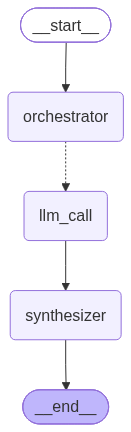

# Introduction and Historical Context

## Defining Scaling Laws

Scaling laws are empirical relationships that describe how a model's performance—typically measured as test loss or cross-entropy—changes as a function of scale. In the context of large language models (LLMs), "scale" is usually decomposed into three primary axes: model size (parameter count, $N$), dataset size (number of training tokens, $D$), and compute budget (FLOPs, $C$). A scaling law expresses loss $L$ as a power-law function of these variables, often with the form:

$$L(N, D) = L_\infty + \left(\frac{N_c}{N}\right)^{\alpha_N} + \left(\frac{D_c}{D}\right)^{\alpha_D}$$

where $L_\infty$ is an irreducible loss floor, $N_c$ and $D_c$ are characteristic scales, and $\alpha_N, \alpha_D$ are scaling exponents. The critical property of these laws is that they are *predictable*: performance improvements follow smooth, monotonic trends across many orders of magnitude, allowing extrapolation from small-scale experiments to large-scale training runs.

## The Historical Arc

### Early Empirical Observations: Kaplan et al. (2020)

The modern era of LLM scaling laws began with Kaplan et al., "Scaling Laws for Neural Language Models" (2020). Training a series of Transformer models ranging from millions to billions of parameters, they observed that test loss followed clean power laws in model size, dataset size, and compute. Key findings included:

- Loss scales as a power law with each of $N$, $D$, and $C$ when the other two are not bottlenecks.
- Larger models are more sample-efficient: they reach a given loss with fewer optimization steps and fewer data points.
- Architectural details (depth vs. width, attention head count) mattered far less than overall scale.

The practical implication was striking: to maximize performance for a fixed compute budget, one should prioritize *model size* over dataset size. This "bigger is better" heuristic directly informed the design of models like GPT-3 (175B parameters), which was trained on roughly 300B tokens—a ratio of under 2 tokens per parameter.

### The Chinchilla Correction: Hoffmann et al. (2022)

Two years later, Hoffmann et al. ("Training Compute-Optimal Large Language Models," 2022) revisited Kaplan's conclusions with a more rigorous experimental design. Training over 400 models across a wide range of sizes and token counts, they found that Kaplan et al. had under-trained models relative to their size. The corrected scaling law implied that model size and dataset size should be scaled *roughly in equal proportion*: for every doubling of parameters, training tokens should also double.

The headline result was Chinchilla, a 70B-parameter model trained on 1.4T tokens, which outperformed the 280B-parameter Gopher on most benchmarks while using less compute. This overturned the prevailing "parameter-maximalist" paradigm and established the compute-optimal frontier: given a fixed FLOP budget $C \approx 6ND$, the optimal allocation satisfies $N \propto C^{0.5}$ and $D \propto C^{0.5}$.

The Chinchilla correction had immediate consequences. It justified training smaller models on far more data, and it reframed data—not parameters—as the binding constraint for many practitioners. It also motivated subsequent work on data quality, deduplication, and synthetic data generation, since the supply of high-quality tokens became the limiting factor.

### Current Practice

Contemporary LLM development operates in a post-Chinchilla landscape with several refinements:

- **Inference-aware scaling.** Because inference cost scales with model size, many deployments deliberately "over-train" smaller models beyond the Chinchilla-optimal point (e.g., Llama 3 8B trained on 15T tokens) to reduce serving costs. This trades training compute for inference efficiency.
- **Data-constrained regimes.** When high-quality data is exhausted, practitioners repeat epochs, mix synthetic data, or accept diminishing returns, and scaling laws have been extended to account for repetition and data quality.
- **Mixture-of-Experts and sparsity.** Scaling laws now incorporate active vs. total parameters, since sparse models decouple capacity from per-token compute.
- **Emergent capabilities.** Beyond loss, researchers study how downstream task performance (reasoning, coding, multilingual ability) scales, sometimes discontinuously, with scale.

## Why Predictable Scaling Matters

The value of scaling laws rests on three practical functions:

1. **Forecasting model performance.** Scaling laws allow teams to predict the loss and downstream capabilities of a model *before* training it. A handful of small runs can be fit to a power law and extrapolated, turning a multi-million-dollar gamble into a calibrated projection.

2. **Allocating compute budgets.** Given a fixed FLOP budget, scaling laws prescribe the optimal split between model size and data. This transforms resource allocation from guesswork into an optimization problem, and it directly informs decisions about cluster procurement, training duration, and checkpointing strategy.

3. **Justifying large training runs.** Because frontier training runs cost tens to hundreds of millions of dollars, stakeholders require evidence that the investment will yield predictable returns. Scaling laws provide that evidence: they convert an uncertain research bet into an engineering plan with quantified expected outcomes and error bars.

In short, scaling laws are the closest thing LLM development has to a physical theory—imperfect, regime-dependent, and occasionally revised, but indispensable for turning scale into a deliberate strategy rather than a brute-force gamble.

---

## Foundational Scaling Laws: Kaplan et al. (2020)

### The Original Power-Law Formulation

Kaplan et al. (2020), in "Scaling Laws for Neural Language Models," established that the cross-entropy loss $L$ of a Transformer language model follows a predictable power law as a function of three primary quantities: model size $N$ (non-embedding parameters), dataset size $D$ (tokens), and compute $C$ (FLOPs). The core empirical relationships, when the other two factors are not bottlenecks, take the form:

$$L(N) = \left(\frac{N_c}{N}\right)^{\alpha_N}, \quad L(D) = \left(\frac{D_c}{D}\right)^{\alpha_D}, \quad L(C) = \left(\frac{C_c}{C}\right)^{\alpha_C}$$

where $N_c$, $D_c$, and $C_c$ are fitted constants and the exponents $\alpha_N \approx 0.076$, $\alpha_D \approx 0.095$, and $\alpha_C \approx 0.050$ were reported. These curves were observed to hold smoothly across more than six orders of magnitude in $N$ and $D$, and roughly four orders of magnitude in $C$ — a striking regularity suggesting that loss is governed by smooth, continuous scaling rather than discrete architectural thresholds.

### Key Findings

**Loss scales as a power law across many orders of magnitude.** The central empirical claim is that performance improves predictably as a power law in scale, with no observed plateau within the tested ranges. This allows extrapolation: one can fit the curve on smaller models and forecast the loss of a model orders of magnitude larger.

**Architecture details matter far less than scale.** Kaplan et al. found that once $N$, $D$, and $C$ are fixed, variations in depth versus width, number of attention heads, feed-forward ratio, and other architectural hyperparameters produce only minor differences in loss. The dominant variable is scale itself, not the precise shape of the network. This was a significant departure from prior intuition that careful architecture design was the primary lever for performance.

**Model size should be prioritized over data when compute is limited.** Perhaps the most consequential prescription: for a fixed compute budget, it is more efficient to train a larger model on fewer tokens than a smaller model on more tokens. The authors derived an allocation rule suggesting that $N$ should be scaled faster than $D$ — specifically, that model size should grow roughly as $C^{0.73}$ while data grows as $C^{0.27}$. This implied that the largest models trainable within a budget should be used, even if they are not trained to convergence on the available data.

### Methodology

The study trained a large family of Transformer language models spanning roughly three orders of magnitude in parameter count (from ~768K to ~1.5B non-embedding parameters), varying $N$, $D$, and $C$ independently where possible.

- **Learning rate schedules:** Each model was trained with a cosine or similar decay schedule, and the learning rate was tuned per model size. The authors noted that the optimal learning rate scales inversely with model width, and that the loss curves are sensitive to the schedule near the end of training.
- **Early stopping and the irreducible loss term:** The fitted power laws include an additive irreducible loss term $L_\infty$, representing the entropy floor of natural language that cannot be reduced by scaling. The functional form is typically $L = L_\infty + (x_c/x)^\alpha$. Models were trained until loss plateaued, and the asymptotic loss was extracted by fitting this form.
- **Compute accounting:** FLOPs were estimated as $C \approx 6ND$ for a forward and backward pass, a standard approximation that ignores attention quadratic terms and embedding costs.

### Limitations Identified by Later Work

The Kaplan et al. prescriptions were substantially revised by subsequent work, most notably Hoffmann et al. (2022), the "Chinchilla" paper. Key limitations:

1. **The data-priority prescription was reversed.** Hoffmann et al. found that Kaplan et al. under-trained models relative to their data. The original study's learning rate schedules and early-stopping criteria caused models to be evaluated before they had fully converged on the available tokens, biasing the fit toward larger models. When trained to convergence, the optimal allocation is roughly equal scaling of $N$ and $D$ — model size and data should grow in tandem, not with model size dominating.

2. **Sensitivity to hyperparameters.** The power-law exponents are not universal constants; they depend on the learning rate schedule, batch size, and other training details. Later work showed that the fitted exponents shift when these are controlled more carefully.

3. **Compute-optimal versus compute-efficient.** The original work conflated the compute-optimal frontier with practical training recipes. Chinchilla demonstrated that for a given compute budget, a smaller model trained on more data can match or exceed a larger, under-trained model — contradicting the "prioritize model size" heuristic.

4. **Architecture and data quality.** Later scaling studies (e.g., on mixture-of-experts, retrieval augmentation, and data curation) showed that architecture and data quality can shift the frontier, meaning the pure power law in $N$, $D$, $C$ is an approximation valid within a particular training regime rather than a universal law.

Despite these revisions, Kaplan et al. (2020) remains foundational: it introduced the empirical framework, the power-law functional form, and the practice of fitting scaling curves to forecast large-model performance — a methodology now standard in frontier model development.

---

# The Chinchilla Correction: Compute-Optimal Training

## Background and Motivation

By 2022, the scaling laws of Kaplan et al. (2020) had become the dominant heuristic for allocating compute in large language model training. The Kaplan laws suggested that, given a fixed compute budget, model size should be scaled aggressively while training data (tokens) grew comparatively slowly—implying that parameters mattered far more than tokens. This guidance shaped a generation of models (GPT-3, Gopher, Megatron-Turing NLG, Jurassic-1) that were enormous relative to the amount of text they saw during training. Hoffmann et al. (2022), in *Training Compute-Optimal Large Language Models* (the "Chinchilla" paper), systematically re-examined this conclusion and found it to be substantially wrong.

## The Core Finding: Models Were Severely Undertrained

Hoffmann et al. trained over 400 language models ranging from 70 million to over 16 billion parameters, varying both model size and training tokens across a wide grid. Their central conclusion was that **model size and training tokens should be scaled in roughly equal proportion** as compute increases. Under the Kaplan prescription, the optimal token-to-parameter ratio was on the order of ~2 tokens per parameter; Hoffmann et al. found the optimum closer to **~20 tokens per parameter**.

The practical consequence was stark: nearly all large models of the era were dramatically undertrained. GPT-3 (175B parameters) had been trained on ~300B tokens—roughly 1.7 tokens per parameter. The Chinchilla authors demonstrated this by training **Chinchilla**, a 70B-parameter model on 1.4 trillion tokens (20 tokens per parameter), which outperformed the 280B-parameter Gopher, the 175B GPT-3, and the 530B Megatron-Turing NLG on a wide range of benchmarks—despite being 4× smaller than Gopher and using the same training compute.

## Three Estimation Approaches

The paper's robustness came from estimating the compute-optimal frontier through three independent methods, which converged on the same answer.

### 1. Fixed Model Sizes (Minimum over Training Curves)

For each of several fixed model sizes, the authors trained on a range of token budgets and recorded final loss. For a given compute budget \(C\), they identified the model size whose training run achieved the lowest loss at that budget. Plotting the loss-minimizing model size against compute yielded a power law: \(N_{opt} \propto C^{a}\) with \(a \approx 0.50\), and correspondingly \(D_{opt} \propto C^{b}\) with \(b \approx 0.50\). Since \(a \approx b\), parameters and tokens should grow in tandem.

### 2. IsoFLOP Profiles

The authors grouped runs by total compute (FLOPs), producing "IsoFLOP" curves: for each fixed compute budget, loss was plotted as a function of model size, yielding a U-shaped curve with a clear minimum. The model size at the minimum defines the compute-optimal allocation for that budget. Fitting these minima across budgets again produced exponents near 0.5 for both \(N\) and \(D\), confirming the first approach.

### 3. Parametric Loss Fitting

The most general approach fit a parametric functional form for loss as a function of model size \(N\) and training tokens \(D\):

\[
L(N, D) = E + \frac{A}{N^{\alpha}} + \frac{B}{D^{\beta}}
\]

where \(E\) is the irreducible loss and \(A, B, \alpha, \beta\) are fitted constants. This functional form captures the diminishing returns from scaling either dimension. Minimizing \(L(N, D)\) subject to the constraint \(C \approx 6ND\) (the standard FLOPs approximation for training) yields closed-form optimal allocations. The fit produced \(\alpha \approx 0.34\), \(\beta \approx 0.28\), and optimal scaling exponents again near 0.5 for both \(N\) and \(D\). This approach also enabled extrapolation to compute budgets far beyond those directly tested.

## The Compute-Optimal Frontier

Combining the three methods, Hoffmann et al. derived the compute-optimal frontier: for a given compute budget \(C\), the optimal model size and token count are approximately

\[
N_{opt}(C) \approx 0.6 \, C^{0.5}, \qquad D_{opt}(C) \approx 12 \, C^{0.5}
\]

(up to constants depending on the fit), implying a token-to-parameter ratio of roughly **20:1** at the optimum. The frontier is a line in \((N, D)\) space along which loss is minimized for each compute level. Points above the line (too many parameters, too few tokens) and below it (too few parameters, too many tokens) are both suboptimal, but the pre-Chinchilla regime had systematically erred toward the former.

## Practical Implications

### Smaller Models, More Data

The immediate lesson was that a smaller model trained on more data can match or exceed a much larger undertrained model at equal compute. Chinchilla (70B, 1.4T tokens) beat Gopher (280B, 300B tokens) using the same compute budget, and matched or exceeded GPT-3 (175B) despite being less than half the size. This inverted the prevailing intuition that "bigger is better" and reframed the design question as one of *balanced* allocation.

### Shift in Industry Training Practices

The correction reshaped training recipes across the field:

- **LLaMA (Meta, 2023)** was trained on 1.0–1.4 trillion tokens for models of 7B–65B parameters—token-to-parameter ratios of roughly 140:1 for the 7B model, far beyond even the Chinchilla optimum. This reflected a further insight: for *inference-optimal* deployment, it is often worth overtraining smaller models on far more tokens than compute-optimal, because inference cost scales with model size while training cost is paid once.
- **Subsequent models** pushed ratios even higher. LLaMA 2 (2023) used 2T tokens; LLaMA 3 (2024) trained an 8B model on 15T tokens (~1,875 tokens per parameter). Mistral, Qwen, Gemma, and others followed similar trajectories.
- **The "overtraining" regime** became standard: models are deliberately trained past the compute-optimal point to reduce inference cost and improve downstream performance per parameter.

### Reconciling with Kaplan

The discrepancy with Kaplan et al. was later attributed to differences in experimental setup—particularly learning rate schedules and the treatment of the token budget. Kaplan et al. used a fixed learning rate schedule tied to the training horizon, which biased their fits toward larger models. Hoffmann et al.'s more careful methodology, including cosine schedules matched to each run's token budget, produced the corrected exponents. This episode became a cautionary tale about the sensitivity of scaling-law conclusions to experimental design.

### Lasting Impact

The Chinchilla correction established compute-optimal training as a first-class concern in LLM development. It shifted the field's default from "scale parameters" to "scale data and parameters together," informed the design of essentially every major model after 2022, and motivated massive investment in data curation and collection—since tokens, not just parameters, became the binding constraint on performance.

---

## Mathematical Formulations and Functional Forms

### Canonical Loss Equations

The empirical study of neural scaling laws begins with two single-variable power-law relationships. For model size \(N\) (typically measured in non-embedding parameters), the loss follows

\[
L(N) = \left(\frac{N_c}{N}\right)^{\alpha},
\]

and for dataset size \(D\) (typically measured in tokens), the loss follows

\[
L(D) = \left(\frac{D_c}{D}\right)^{\beta}.
\]

These forms capture the observation that loss decreases as a power law in each resource, with diminishing returns governed by the exponents \(\alpha\) and \(\beta\). The constants \(N_c\) and \(D_c\) are *critical* scales: they set the point at which the power-law term equals unity, and they absorb units so that the ratio inside the parentheses is dimensionless. In practice they are fitted nuisance parameters rather than quantities with independent physical meaning, though they are often interpreted as the scale at which the resource becomes "large enough" for the power-law regime to dominate.

The two single-variable laws are combined into a joint functional form that separates an irreducible floor from two additive power-law penalties:

\[
L(N, D) = E + \frac{A}{N^{\alpha}} + \frac{B}{D^{\beta}}.
\]

Here \(E\) is the **irreducible loss** (also called the entropy floor or Bayes error): the loss that cannot be reduced by adding more parameters or more data, arising from the intrinsic noise and ambiguity of the task. \(A\) and \(B\) are fitted coefficients that absorb the critical scales, so that \(A = E\,N_c^{\alpha}\) and \(B = E\,D_c^{\beta}\) when the single-variable forms are written with the same floor. The exponents \(\alpha\) and \(\beta\) control the steepness of the returns to scale: larger exponents mean faster improvement per doubling of the resource, while smaller exponents mean the curve flattens quickly. Empirically, \(\alpha\) and \(\beta\) are typically in the range \(0.05\)–\(0.1\) for language models, though reported values vary with architecture, tokenizer, and the range of scales probed.

### Fitting the Exponents

The exponents are estimated by fitting the loss curve across a grid of model sizes and dataset sizes. A standard protocol is to train a family of models at several \(N\) and \(D\), then perform a nonlinear least-squares fit of \(L(N,D)\) to the observed losses, often in log-space to stabilize the fit. Because \(E\), \(A\), \(B\), \(\alpha\), and \(\beta\) are jointly identified only up to the range of data available, fits are sensitive to the smallest and largest scales included. A common practical approach is to fit the single-variable laws first—holding \(D\) fixed while varying \(N\), and vice versa—to obtain initial estimates of \(\alpha\) and \(\beta\), then refine all five parameters jointly. The fitted exponents are then used to extrapolate loss to scales not directly trained, which is the primary practical value of the formulation.

### Compute-Optimal Allocation

Given a fixed compute budget \(C\), the question of how to split it between model size and dataset size is answered by minimizing \(L(N,D)\) subject to a compute constraint. If compute scales as \(C \propto N D\) (or more generally \(C \propto N^{a} D^{b}\) with \(a+b=1\) under a linear compute model), the optimal allocation follows power laws:

\[
N \propto C^{a}, \qquad D \propto C^{b}, \qquad a + b = 1.
\]

The exponents \(a\) and \(b\) are determined by the loss exponents: minimizing \(A/N^{\alpha} + B/D^{\beta}\) under \(ND = C\) yields \(a = \beta/(\alpha+\beta)\) and \(b = \alpha/(\alpha+\beta)\). This is the mathematical basis of the *compute-optimal* scaling laws popularized by Kaplan et al. and later revised by Hoffmann et al. (Chinchilla). The Chinchilla result—that models were significantly undertrained relative to their size—corresponds to fitted exponents implying \(a \approx b \approx 0.5\), i.e., model size and dataset size should grow in roughly equal proportion. Earlier work had implied a larger \(a\), favoring bigger models over more data, which led to the opposite allocation. The discrepancy illustrates how sensitive the allocation prescription is to the fitted exponents and to the assumed compute model.

### Alternative Functional Forms

The canonical additive power law is an approximation, and several alternatives have been proposed to better match empirical data:

- **Broken power laws.** Loss curves sometimes exhibit a change in exponent at a particular scale, producing two power-law regimes with different \(\alpha\) or \(\beta\). A broken power law introduces a breakpoint and separate exponents on either side, which can capture a transition from a data-limited to a model-limited regime.
- **Exponential saturation.** Instead of a pure power law, the loss may approach the floor exponentially, e.g., \(L(N) = E + A e^{-kN}\). This form is motivated by the idea that each additional unit of capacity yields a constant *fractional* reduction in the reducible loss, rather than a constant power-law reduction.
- **Sigmoidal or logistic forms.** Some studies find that loss follows an S-shaped curve in log-resource space, with a slow start, a steep middle, and a plateau. Logistic or Gompertz functions can fit such behavior and naturally incorporate both a floor and a ceiling.
- **Mixture and multi-term forms.** More elaborate models add terms for other resources (e.g., compute, inference budget) or allow the exponents to depend on the regime, producing piecewise or hierarchical formulations.

These alternatives are not merely curve-fitting exercises: the choice of functional form determines the extrapolated loss at scales far beyond the training data, and therefore determines the recommended compute-optimal allocation. A form that predicts a slower approach to the floor will favor larger models, while one that predicts faster saturation will favor more data. Consequently, the mathematical formulation is not a neutral description but a modeling assumption with direct consequences for how resources should be spent.

---

# Scaling Laws for Downstream Performance and Emergent Abilities

## The Gap Between Loss and Task Performance

Pretraining loss follows remarkably clean power laws in model size, dataset size, and compute (Kaplan et al. 2020; Hoffmann et al. 2022). Yet the quantities practitioners actually care about—accuracy on reasoning benchmarks, pass@k for code generation, few-shot performance on novel tasks—do not map onto loss in any simple, monotonic way. Two models with nearly identical validation loss can differ substantially on downstream tasks, and improvements in loss often translate into highly uneven gains across benchmarks. This disconnect is the central puzzle of downstream scaling: loss is a smooth, aggregate measure over a token distribution, while task performance is a discrete, thresholded, and often discontinuous function of model capability.

## The Emergent Abilities Debate

Wei et al. (2022) documented "emergent abilities": capabilities that are near-random at small scales and then appear abruptly once models cross a critical size. Examples included multi-step arithmetic, chain-of-thought reasoning, and certain translation tasks, where performance jumped from near-zero to well above chance over a narrow range of scale. This framing suggested that some capabilities are qualitatively new and fundamentally unpredictable from smaller models.

Schaeffer et al. (2023) challenged this interpretation, arguing that apparent emergence is largely an artifact of how we measure performance. They showed that when the same underlying model outputs are scored with continuous or smoother metrics (e.g., token-level accuracy or log-likelihood-based measures instead of exact-match accuracy), the "jumps" become smooth, gradual improvements. Under this view, the model's capability improves continuously with scale; the discontinuity is introduced by the researcher's choice of a nonlinear, all-or-nothing metric. A task requiring an exact multi-step answer will show a sharp transition because partial credit is discarded, whereas a metric that rewards partial progress reveals a smooth curve.

The debate remains unsettled. Proponents of genuine emergence point to cases where smooth metrics also show sharp transitions, or where the transition is robust across metric choices. Critics note that many claimed emergent abilities vanish under better-controlled evaluation, prompting, and metric design. The practical upshot is that "emergence" is at least partly a statement about measurement, not only about the model.

## Scaling Laws for Downstream Metrics

Empirical work on downstream scaling has produced a mixed picture:

- **Accuracy on classification and multiple-choice tasks** often follows approximately sigmoidal or power-law curves in model size, but with task-specific exponents and offsets. Some tasks improve steadily; others plateau early.
- **pass@k for code generation** tends to improve smoothly with scale and with sampling budget, and can be modeled reasonably well by power laws in compute, though the exponent varies by benchmark (e.g., HumanEval vs. MBPP).
- **Benchmark aggregates** (e.g., average over many tasks) often look smoother than individual tasks, because averaging over heterogeneous thresholds washes out sharp transitions.
- **Reasoning and multi-step tasks** are the most likely to exhibit sharp transitions under exact-match metrics, consistent with the Schaeffer et al. critique.

There is no single universal downstream scaling law. The shape depends on the task, the metric, the prompting strategy, and the sampling procedure. Smooth power laws are common for continuous or partial-credit metrics; sharp transitions are common for discrete, all-or-nothing metrics.

## Practical Difficulty of Predicting Capability Thresholds

Because loss does not directly determine task performance, predicting when a specific capability will "turn on" is difficult. A model may cross a loss threshold that correlates with improved benchmark scores on average, but individual capabilities can appear earlier or later, or not at all, depending on architecture, data mixture, tokenizer, and evaluation protocol. This makes capability forecasting from loss alone unreliable. Practitioners typically resort to:

- **Direct evaluation at multiple scales** to fit task-specific curves, which is expensive and only valid for the tasks measured.
- **Extrapolation from smaller models**, which is risky when the metric is discontinuous or when the task requires compositional skills not present at small scale.
- **Ensembling and sampling**, which can shift the effective threshold by trading compute for reliability.

The honest summary is that loss scaling is a reliable guide to average model quality, but not to specific downstream capabilities. Emergent-looking transitions are real in the sense that they appear in measured performance, but they are often better explained by metric discontinuities than by fundamental discontinuities in the model's underlying competence. Predicting exactly when a given capability will emerge remains an open problem, and current evidence suggests it is not solvable from loss alone.

---

# Beyond the Basics: Data Quality, Repetition, and Mixture

## Data Quality and the Shifting Scaling Curve

The classical scaling laws treat all tokens as interchangeable units of compute. In practice, however, the *quality* of the data shifts the entire scaling curve rather than merely moving a model along it. Empirically, models trained on curated, high-quality corpora (e.g., filtered web text, textbooks, or carefully deduplicated code) reach a given loss with substantially fewer tokens than models trained on unfiltered crawl data. This means the effective compute-optimal frontier is not a fixed function of token count but a function of the *information density* of the data.

Several mechanisms drive this:

- **Noise and redundancy act as a tax.** Low-quality tokens consume model capacity and gradient steps without contributing new signal, effectively inflating the dataset size needed to reach a target loss.
- **Quality filtering changes the exponent.** Some studies find that aggressive filtering can improve the scaling exponent itself, not just the intercept, implying that quality and quantity are not fully substitutable.
- **Diminishing returns to filtering.** Beyond a point, filtering removes useful long-tail signal, and the marginal benefit of additional curation shrinks.

The practical implication is that "more data" and "better data" are not equivalent levers, and scaling laws fit on raw token counts can badly mispredict the behavior of a curated pipeline.

## Repetition and Diminishing Returns

When unique data is exhausted, practitioners repeat tokens. Repetition follows a characteristic pattern:

- **Early epochs are nearly as valuable as fresh data.** The first few passes over a corpus yield returns close to (though below) those of new tokens.
- **Returns decay rapidly.** By roughly the fourth epoch, additional repetitions contribute very little; beyond that, the marginal value approaches zero and can even degrade performance through overfitting to surface statistics.
- **Repetition interacts with model size.** Larger models extract more value from a single epoch and saturate faster on repeated data, so the "useful epoch budget" shrinks as scale grows.

This has a direct consequence for compute-optimal training: repeating a small high-quality dataset many times is generally inferior to training once on a larger, moderately filtered dataset, unless the repeated data is of exceptionally high quality. The scaling law for repeated data is therefore best modeled as a *decaying* contribution per epoch rather than a linear accumulation of tokens.

## Data Mixture Scaling Laws

Real training corpora are mixtures over domains (web, code, books, math, multilingual text). The mixture proportions materially affect loss, and this dependence can itself be described by scaling laws:

- **Domain-specific exponents.** Each domain has its own loss-vs-tokens curve. The aggregate loss is a weighted combination, so shifting mixture weights changes which domain's exponent dominates at a given scale.
- **Optimal mixtures drift with scale.** A mixture that is optimal for a small model is often suboptimal for a large one. Domains with steeper scaling exponents (e.g., code or formal math) tend to warrant larger shares as compute grows, while shallow-exponent domains (e.g., generic web chatter) should be down-weighted.
- **Mixture as a first-class hyperparameter.** Treating mixture weights as tunable, scale-dependent variables—rather than fixed constants—is now standard in frontier training recipes.

## Curriculum, Ordering, and the Effective Dataset Size

The *order* in which data is presented also matters, though its effect is smaller than quality or mixture:

- **Curriculum effects.** Presenting easier or cleaner data early and harder or noisier data later can modestly improve final loss, but the gains are typically smaller than those from filtering or reweighting.
- **Ordering sensitivity.** Some domains benefit from being interleaved rather than blocked; others (e.g., code) can suffer if presented too late.
- **Effective vs. raw dataset size.** Because quality, deduplication, and mixture all change how much *useful* signal a token carries, the "effective" dataset size—the number of unique, informative tokens—can be far smaller than the raw token count. Two corpora with identical raw sizes can differ by an order of magnitude in effective size, and scaling laws should be fit against the effective quantity.

## Synthetic Data and Its Scaling Properties

Synthetic data (model-generated text, distilled reasoning traces, augmented code) has become a major component of modern corpora, with distinct scaling behavior:

- **Distillation can compress signal.** Well-generated synthetic data can pack more task-relevant information per token than raw web text, effectively shifting the scaling curve upward.
- **Model collapse risk.** Training predominantly on self-generated data without grounding leads to distributional narrowing and degradation, a form of negative scaling where more synthetic tokens *hurt*.
- **Verification is the key variable.** Synthetic data that can be filtered or verified (e.g., code that compiles, math with checkable answers) scales well; unverifiable synthetic text scales poorly and can amplify errors.
- **Mixture with real data.** The best results typically come from mixing synthetic and real data, where synthetic data supplies density and real data supplies diversity and grounding.

The overarching lesson is that scaling behavior is governed not by raw token counts but by the *effective, deduplicated, well-mixed, and appropriately ordered* information content of the training distribution—and synthetic data is best understood as a tool that raises information density when it can be verified, and a liability when it cannot.

---

# Architecture, Optimization, and Transfer Scaling

## Architectural Scaling Laws

Scaling laws were originally characterized for dense Transformer language models, where loss follows a power law in parameters $N$, dataset size $D$, and compute $C$ (Kaplan et al., 2020; Hoffmann et al., 2022). Subsequent work has asked whether these exponents are invariant to architectural choices or whether each architecture induces its own scaling surface.

**Mixture-of-Experts (MoE).** MoE decouples total parameters from per-token compute by activating a sparse subset of experts. Empirically, MoE models exhibit power-law scaling in *active* parameters that is comparable to—and sometimes slightly better than—dense models at matched active compute, while total parameter count grows much faster for a given loss (Clark et al., 2022; Du et al., 2022). The scaling behavior depends on the granularity of routing (number of experts, top-$k$), load-balancing losses, and expert capacity. A recurring finding is that sparse models follow a modified scaling law in which the effective parameter count is the number of *activated* parameters, with a correction term for routing inefficiency. This means the "compute-optimal" frontier for MoE differs from dense models: one should scale total parameters and data jointly, but the optimal token-to-active-parameter ratio shifts.

**Sparsity beyond MoE.** Structured and unstructured sparsity (pruning, sparsely-gated layers) generally degrade the loss at a fixed parameter budget, but can recover dense-equivalent quality when the *total* (not active) parameter count is scaled up. The scaling exponent for sparse models is often steeper in the sparse dimension, implying that sparsity buys compute efficiency at the cost of a larger memory footprint—an architecture-specific trade-off not captured by a single universal law.

**Attention variants.** Alternatives to softmax attention—linear attention, state-space models (S4/Mamba), and hybrid architectures—show power-law scaling in their own right, but with different exponents and different data-efficiency regimes. For example, state-space models tend to underperform Transformers at small scale on recall-heavy tasks but close the gap or surpass them at larger scale on long-context tasks, indicating that the *ranking* of architectures can be scale-dependent. This is strong evidence against a single universal scaling law: the exponents and even the ordering of architectures vary with the task distribution and the scale regime.

## Optimizer and Hyperparameter Transfer

A central practical question is whether optimal hyperparameters found at small scale transfer to large scale. Naïve transfer fails: the optimal learning rate typically decreases with model width, and other hyperparameters drift, forcing expensive re-tuning at every scale.

**Maximal Update Parameterization ($\mu$P).** $\mu$P (Yang & Hu, 2021; Yang et al., 2022) specifies layer-wise initialization and learning-rate scaling (e.g., $1/\text{width}$ for many layers) such that the optimal hyperparameters—learning rate, initialization variance, and even optimizer $\epsilon$—are *scale-invariant*. Under $\mu$P, hyperparameters tuned on a small proxy model transfer zero-shot to a much larger model, a result demonstrated up to billions of parameters. This is a form of *hyperparameter scaling law*: rather than predicting loss, it predicts the invariance of the optimum.

**Learning-rate scaling.** Standard parameterization (SP) requires the learning rate to shrink as width grows, often as $1/\sqrt{\text{width}}$ or steeper, whereas $\mu$P keeps it constant. The choice of parameterization therefore changes the *shape* of the hyperparameter scaling law, not just its constants. Similar considerations apply to batch size: the critical batch size grows with model size and dataset size, and the optimal learning rate scales with batch size in a predictable way (McCandlish et al., 2018).

**Implications for tuning at scale.** Because full-scale hyperparameter sweeps are prohibitively expensive, the practical recipe is: (i) adopt a parameterization ($\mu$P) that makes optima scale-invariant; (ii) tune on a small proxy; (iii) transfer. Where invariance does not hold, one fits a *hyperparameter scaling law* (e.g., learning rate vs. width) from a few small runs and extrapolates. This reframes hyperparameter tuning as a scaling-law problem rather than a per-scale search.

## Transfer Learning Scaling Laws

Transfer learning introduces a source–target structure: performance on a target distribution depends on source model size, source data, and the distribution shift between source and target.

**Transfer across model sizes.** Fine-tuning a larger pretrained model generally yields better target performance, but the *marginal* benefit of scale diminishes and can saturate or even reverse under large distribution shift (e.g., domain mismatch or task mismatch). Transfer scaling laws often take the form of a power law in source compute plus a shift-dependent offset, where the offset grows with the divergence between source and target distributions. In some regimes, a smaller model pretrained on in-domain data outperforms a larger out-of-domain model—an architecture- and data-specific effect.

**Transfer across data distributions.** The scaling exponent for transfer depends on the *effective* data overlap between source and target. When distributions are close, target loss scales similarly to in-domain loss; when they diverge, the exponent flattens and more target data is required to recover. This has been formalized in terms of a transfer gap that scales with distributional distance, and in "scaling laws for transfer" (Hernandez et al., 2021) where pretraining compute and fine-tuning data trade off along a predictable frontier.

**Upstream–downstream coupling.** A robust empirical pattern is that downstream performance is a function of upstream loss (or compute) that is approximately linear in log-loss over a wide range, with a slope that depends on the task. This suggests a *two-stage* scaling law: upstream scaling determines a representation quality, and downstream scaling determines how efficiently that quality is converted into task performance.

## Are Scaling Laws Universal or Architecture-Specific?

The evidence points to a middle position:

- **Functional form is often universal.** Loss vs. compute/parameters/data frequently follows a power law with a similar functional shape across architectures.
- **Exponents and constants are architecture- and task-specific.** MoE, linear attention, and state-space models each have their own exponents, and the ranking of architectures can change with scale.
- **Hyperparameter optima are parameterization-specific.** $\mu$P makes optima invariant; SP does not. The "law" governing hyperparameters is therefore a property of the parameterization, not of the architecture alone.

A useful framing is that scaling laws are *conditional*: given an architecture family, parameterization, optimizer, and data distribution, a power law with specific exponents describes the loss. Changing any of these conditions changes the exponents, so there is no single universal law—only a family of laws indexed by these choices.

## Implications for Hyperparameter Tuning at Scale

1. **Adopt scale-invariant parameterizations.** $\mu$P (or equivalent) converts hyperparameter tuning from a per-scale cost into a one-time small-scale cost.
2. **Fit hyperparameter scaling laws where invariance fails.** When optima drift (e.g., batch size, weight decay), fit a power law from a few small runs and extrapolate rather than sweeping at scale.
3. **Treat architecture choice as a scaling-law choice.** Comparing architectures at a single scale is unreliable; compare their scaling exponents and crossover points.
4. **Budget for transfer, not just pretraining.** The optimal allocation between source scale and target fine-tuning data depends on distributional distance, which should be measured, not assumed.
5. **Expect scale-dependent rankings.** A model that wins at small scale may lose at large scale (and vice versa), so architecture decisions should be made on the projected frontier, not on a single operating point.

In summary, scaling laws are best understood as a *conditional* framework: universal in functional form, specific in exponents, and tightly coupled to parameterization and data distribution. This makes them powerful for extrapolation and hyperparameter transfer, but only when the conditions under which they were measured are made explicit.

---

# Inference-Time Scaling and Test-Time Compute

## From Training Scaling to Inference Scaling

The original scaling paradigm of deep learning held that capability was primarily a function of training compute: bigger models, trained on more data, for longer, produced better results. Inference was treated as a fixed cost—a single forward pass through the network to produce an answer. The newer paradigm inverts part of this assumption. Instead of spending compute once during training, models can spend additional compute *at inference time* to improve their outputs on a per-query basis. This is test-time compute scaling, and it has become a first-class axis of capability alongside model size and training data.

The core intuition is that many tasks—mathematical reasoning, code generation, multi-step planning—have a verifiable or at least checkable structure. If a model can generate multiple candidate solutions, explore alternative reasoning paths, or extend its chain of thought, it can convert raw inference compute into accuracy. This is qualitatively different from simply making the model larger, because the extra compute is spent on the specific problem instance rather than amortized across all inputs.

## Mechanisms for Spending Test-Time Compute

Several distinct mechanisms have emerged, and they are often combined.

**Chain-of-thought length.** The simplest form of test-time scaling is letting the model generate longer reasoning traces before committing to an answer. Longer chains allow the model to decompose problems, check intermediate steps, and recover from early errors. Empirically, accuracy on reasoning benchmarks rises with the number of reasoning tokens, though with diminishing returns and a risk of "overthinking" on easy problems. Some models are explicitly trained to modulate chain length, producing short chains for simple queries and long ones for hard ones.

**Sampling and best-of-n.** Rather than taking a single greedy decode, the model samples *n* independent completions and a verifier or reward model selects the best. Accuracy improves with *n*, typically following a power-law or logarithmic curve. The quality of the verifier is the binding constraint: if the selector is weak, additional samples yield little. Best-of-n is attractive because it is embarrassingly parallel and requires no changes to the base model.

**Self-consistency.** A special case of sampling where the model generates multiple reasoning paths and the final answer is chosen by majority vote. This exploits the fact that correct reasoning paths tend to converge on the same answer, while errors are more idiosyncratic. Self-consistency reliably improves accuracy on arithmetic and commonsense reasoning, and its gains scale with the number of sampled paths.

**Search.** More structured than independent sampling, search methods explore a tree or graph of partial solutions, using a process reward model (PRM) to score intermediate steps and guide expansion. Techniques include beam search over reasoning steps, Monte Carlo tree search, and best-first exploration. Search can be substantially more compute-efficient than best-of-n because it prunes unpromising branches early, but it requires a reliable step-level verifier and careful engineering to avoid reward hacking.

## Empirical Scaling Laws for Test-Time Compute

The key empirical finding is that test-time compute exhibits its own scaling laws, roughly analogous to training scaling laws but with different exponents and saturation behavior. As inference compute increases—whether through more samples, longer chains, or deeper search—performance on reasoning tasks improves predictably, often following a log-linear relationship over a substantial range before plateauing.

Crucially, these curves are not universal. The returns to test-time compute depend on:

- **Task difficulty.** Easy problems saturate quickly; hard problems continue to benefit from more compute.
- **Base model capability.** A model that lacks the underlying skill cannot be rescued by more sampling—it will simply generate more confidently wrong answers.
- **Verifier quality.** The ceiling on best-of-n and search is set by how well the model or a separate verifier can distinguish correct from incorrect outputs.

This has led to the notion of an *inference compute budget* as a tunable hyperparameter, analogous to learning rate or batch size, that can be optimized per deployment.

## The Trade-off Between Model Size and Inference Compute

Perhaps the most consequential finding is that **smaller models with more inference compute can match larger models with less**. A 7B model given thousands of samples and a good verifier can outperform a 70B model given a single greedy decode on certain reasoning benchmarks. This is not a free lunch—the smaller model still has a lower ceiling and may fail on tasks requiring knowledge or skills it never acquired—but within a task distribution, the trade-off is real and quantitatively characterized.

The practical implication is that the "best" model for a given accuracy target is no longer simply the largest one. Instead, there is a frontier of (model size, inference compute) pairs that achieve comparable performance, and the optimal point depends on the relative costs of training, storage, and inference. For latency-sensitive applications, a larger model with a single pass may win. For throughput-oriented or batch applications where latency is less critical, a smaller model with aggressive sampling can be more cost-effective.

## Implications for Deployment Cost and Budget Balance

Test-time scaling shifts the economics of AI deployment in several ways.

**Inference cost becomes variable and workload-dependent.** A single forward pass has a fixed cost per query. Best-of-n multiplies that cost by *n*; search can multiply it further. This makes inference budgets harder to predict and creates a direct trade-off between accuracy and serving cost. Providers must decide whether to expose this trade-off to users (e.g., a "high-effort" mode) or absorb it internally.

**The training/inference balance shifts.** Historically, training dominated the compute budget for frontier models, with inference a smaller recurring cost. As test-time scaling becomes standard, inference compute can rival or exceed training compute over a model's lifetime, especially for high-traffic applications. This changes the calculus for model developers: a smaller, cheaper-to-serve model that relies on inference scaling may be more economical than a larger model that solves problems in one pass.

**Verification becomes a first-class component.** Best-of-n and search depend on verifiers, whether learned reward models, formal checkers, or self-verification. Investing in verifier quality can be more cost-effective than investing in base model scale, because it raises the ceiling on what inference compute can buy.

**Latency and user experience.** More inference compute means longer response times unless parallelism is used. Best-of-n parallelizes well; sequential chain-of-thought and search do not. This creates a tension between accuracy and interactivity that deployment architectures must resolve, often through speculative execution, caching, or tiered service levels.

**Diminishing returns and overthinking.** Not all queries benefit from more compute. Easy queries can be answered correctly with a single pass, and forcing long chains or many samples wastes compute and can even degrade accuracy through overthinking. Adaptive compute allocation—deciding per query how much inference budget to spend—is an active area of research and a key lever for cost control.

In summary, test-time compute scaling reframes inference as a controllable resource rather than a fixed cost. It offers a path to higher accuracy without retraining, but it also introduces new trade-offs in cost, latency, and verifier design. The practical frontier is no longer a single model but a family of (model, inference budget) configurations, and the optimal choice depends on the deployment context.

---

# Practical Implications, Criticisms, and Limitations

## Practical Implications

Scaling laws convert a largely empirical engineering discipline into something closer to a forecasting exercise. Their most immediate use is **compute budgeting**: given a target loss and a fixed compute budget, a fitted law predicts the model size and token count that minimize loss, allowing teams to allocate FLOPs across parameters, data, and training duration before committing to a run. This is the logic behind compute-optimal prescriptions such as training smaller models on more data (or vice versa) depending on the budget regime.

**Model sizing** follows directly: rather than guessing at architecture scale, practitioners interpolate along the fitted curve to select a parameter count whose predicted loss meets a downstream requirement. **Data acquisition** is informed by the same curves—if loss falls predictably with tokens, the marginal value of additional data can be estimated, guiding decisions about collection, licensing, or synthetic generation. Finally, scaling laws support **go/no-go decisions** for large runs: by fitting on small-scale pilots and extrapolating, teams can estimate whether a multi-million-dollar training run is likely to clear a performance threshold, and whether the expected gain justifies the cost. In practice these forecasts are treated as priors, not guarantees, and are paired with smaller validation runs.

## Criticisms and Limitations

**Extrapolation risk.** Scaling laws are fitted within a bounded range of model sizes, data volumes, and compute. Predictions outside that range—especially across architectural changes, new optimizers, or qualitatively different data—are extrapolations whose error is not captured by the fit's in-range residuals. A law that holds across three orders of magnitude may break at the next one.

**Sensitivity to hyperparameters and data distribution.** Fitted exponents and coefficients depend on learning rate schedules, batch size, initialization, and tokenizer choices. A law fitted under one configuration can mispredict under another, and shifts in data distribution (domain, language, quality, duplication) can move the curve itself rather than a point along it. This makes laws descriptive of a *regime* rather than universal.

**The irreducible loss floor.** Most parameterizations include an additive constant representing loss that cannot be reduced by scaling. This floor is often treated as fixed, but it is an empirical artifact: it may reflect data entropy, label noise, or the objective itself, and its value is not guaranteed to be stable as scale grows. Treating it as a hard limit can understate what further scaling or better data might achieve.

**Is loss the right objective?** Scaling laws typically predict cross-entropy or perplexity, which are smooth and measurable but only loosely coupled to downstream capabilities. Emergent abilities, reasoning, factuality, and safety properties do not scale monotonically with loss, so a law that accurately forecasts loss may say little about whether a model will be useful or safe for a given task.

## Tension Between Scaling and Efficiency

Scaling laws describe returns to *more* compute, data, and parameters, but they sit in tension with algorithmic progress, which shifts the curve itself. Better architectures, optimizers, data curation, and training recipes can achieve the same loss at lower cost, meaning a law fitted today may overstate the compute needed tomorrow. This creates a strategic dilemma: investing in scale assumes the curve is stable, while investing in efficiency assumes it can be moved. In practice both matter, and the relevant question is often the *exchange rate* between the two—how much algorithmic improvement substitutes for how much compute.

## Data Limits Versus Compute Limits

A further limitation is that scaling laws are typically fit with data as an abundant input, but high-quality text (and other modalities) is finite. If compute continues to grow faster than usable data, the binding constraint shifts from FLOPs to tokens, and compute-optimal prescriptions change accordingly—favoring smaller models, more epochs, or synthetic and multimodal data. Whether data or compute binds first is regime-dependent and contested, but the possibility that data limits arrive before compute limits is a central caveat for any long-horizon forecast built on current scaling laws.

---

# Future Directions and Open Questions

## Do Scaling Laws Survive Multimodality and Agency?

The clean power-law relationships established for unimodal language models rest on a simplifying assumption: that loss is a smooth function of compute, parameters, and tokens, with a single well-behaved data distribution. Multimodal models break this assumption in ways we do not yet understand. When a model ingests text, images, audio, and video, the effective data distribution becomes heterogeneous, and it is unclear whether a single scaling exponent can describe learning across modalities or whether each modality has its own frontier with distinct exponents. Early evidence suggests that cross-modal transfer can *improve* sample efficiency—vision may regularize language representations—but it can also introduce interference, where gradient signals from one modality degrade performance on another. The open question is whether there exists a unified multimodal scaling law, or whether the field will fragment into modality-specific laws coupled by transfer terms.

Agentic regimes pose an even sharper challenge. An agent's performance depends not only on model scale but on the length of its action horizon, the quality of its environment, and its ability to recover from errors. This introduces a new axis—*interaction compute*—that has no analogue in static next-token prediction. Does agentic capability scale with the same exponents, or does it exhibit threshold behavior, where a model below some scale cannot chain actions reliably at all? If thresholds exist, the smooth extrapolation that made scaling laws so useful for forecasting breaks down, and we would need a phase-transition framework rather than a power-law one.

## Data Exhaustion and the Synthetic Data Question

The most immediate empirical constraint on continued scaling is the finite supply of high-quality human text. Estimates of when we exhaust the stock of usable web text range from roughly 2026 to 2032, depending on filtering standards and multilingual inclusion. This raises a question that is simultaneously technical and epistemological: can synthetic data substitute for human data without inducing model collapse?

The theoretical case for collapse is intuitive—training on self-generated data can amplify errors and narrow the distribution—but the empirical picture is more nuanced. Careful filtering, mixing with real data, and iterative refinement have all been shown to mitigate degradation. The open question is whether there is a *fundamental* information-theoretic limit to self-improvement, or whether synthetic data is simply a harder engineering problem. If the latter, scaling laws may survive data exhaustion with modified constants; if the former, we face a hard ceiling that no amount of compute can overcome. Distinguishing these requires controlled experiments that separate the effects of distribution shift from those of genuine information loss.

## Reasoning, Long Context, and the Loss–Capability Gap

Reasoning models and long-context models expose a growing divergence between training loss and downstream capability. A model can achieve lower perplexity while performing worse on multi-step reasoning, and vice versa. This suggests that loss—the quantity scaling laws predict—is an increasingly poor proxy for what we actually care about. The open problem is to identify the *right* scaling variable for reasoning: is it the number of reasoning tokens, the depth of the computation graph, the diversity of training tasks, or something else entirely?

Long context introduces a related puzzle. Attention is quadratic in sequence length, so naive scaling hits a compute wall, but architectural innovations (sparse attention, state-space models, retrieval augmentation) shift the frontier without changing the underlying scaling law. Whether these innovations merely delay the wall or genuinely change the exponent is unresolved. More fundamentally, we do not know whether long-context capability scales smoothly or whether it requires qualitatively different training objectives—a question with direct implications for whether "just scale it" remains a viable strategy.

## The Loss–Capability Relationship

Underlying all of the above is a deeper question: why does loss predict capability at all? The empirical correlation is strong in the regimes we have explored, but it is not a law of nature. It may hold because both loss and capability are driven by a common latent factor—effective model complexity relative to task complexity—or it may be a coincidence of the tasks we happen to measure. If the relationship is causal, scaling loss will continue to yield capability; if it is correlational, we may hit a regime where loss improves while capability stagnates.

This matters enormously for forecasting. Current predictions of AGI timelines often extrapolate from loss curves to capability curves, implicitly assuming the relationship is stable. A single well-documented case of loss–capability decoupling at scale would falsify a wide class of forecasts. Conversely, if the relationship holds through several more orders of magnitude, it would strongly support the view that capability is a smooth function of scale.

## Algorithmic Progress and the Shifting Frontier

Scaling laws are typically stated for a fixed algorithm, but algorithms change. The history of deep learning is a history of algorithmic improvements that shift the frontier—better optimizers, architectures, and training objectives that achieve the same loss with less compute. The open question is how to model this. Is algorithmic progress a constant multiplicative factor, an accelerating trend, or a series of discrete jumps? If it is accelerating, then compute-based forecasts may *underestimate* progress; if it is decelerating (because we have picked the low-hanging fruit), they may overestimate it.

There is also a feedback loop: larger models enable better algorithms (e.g., using models to design architectures or curate data), which in turn enable larger models. Whether this loop is stable or explosive is unknown, and it is one of the key uncertainties in any long-horizon forecast.

## A Post-Scaling-Law Era?

What would it mean for scaling laws to fail? Not necessarily that progress stops, but that the smooth, predictable relationship between compute and capability breaks down. This could take several forms:

- **Saturation**: capability plateaus despite continued compute increases, because the task distribution is exhausted or the architecture has a hard ceiling.
- **Discontinuity**: capability jumps unpredictably, making extrapolation useless.
- **Decoupling**: loss continues to improve but capability does not, or vice versa.
- **Diminishing returns**: exponents shrink toward zero, so each doubling of compute yields ever-smaller gains.

Each of these would falsify different predictions. Saturation would falsify the "scale is all you need" thesis; discontinuity would falsify smooth extrapolation; decoupling would falsify loss-based forecasting; diminishing returns would falsify the most aggressive timeline estimates. The evidence that would distinguish these scenarios is not yet in hand, but it is the central empirical question of the next few years.

## What Would Falsify Current Predictions?

Current predictions—that capability scales smoothly with compute, that synthetic data can sustain progress, that loss predicts capability—are falsifiable in principle. Specific tests include:

1. **A documented case of loss–capability decoupling at scale**, where a larger model with lower loss performs worse on a held-out reasoning benchmark.
2. **A multimodal scaling law that requires modality-specific exponents**, undermining the unified view.
3. **Model collapse under synthetic data** that cannot be mitigated by filtering or mixing.
4. **Agentic performance that fails to improve with scale** beyond a threshold, indicating a qualitative barrier.
5. **Algorithmic progress that decelerates sharply**, suggesting we have exhausted the easy wins.

None of these have been conclusively observed, but none have been conclusively ruled out either. The honest position is that scaling laws are a remarkably successful empirical regularity whose domain of validity is not yet fully mapped. The most valuable future work may not be in extending the laws, but in probing their boundaries—finding the regimes where they break, and understanding why.

---

# Conclusion

Scaling laws have matured from an empirical curiosity into a predictive engineering tool. The core insight—that loss follows smooth, predictable power laws in model size, data, and compute—allows practitioners to forecast the performance of models that have not yet been trained, allocate resources before committing to expensive runs, and identify when a training configuration is misaligned with its budget. This predictive capacity is what separates modern large-model development from earlier eras of trial-and-error scaling.

The field's understanding has evolved through three distinct phases. Kaplan et al. (2020) established that loss scales as a power law in model size, data, and compute, and initially suggested that model size should be prioritized over data. Chinchilla (Hoffmann et al., 2022) corrected this, showing that models were substantially undertrained and that compute-optimal training requires scaling parameters and tokens in roughly equal proportion. The current frontier extends this logic beyond pretraining: inference-time scaling laws demonstrate that allocating additional compute at generation—through chain-of-thought, sampling, or search—yields predictable gains, and that these gains interact with pretraining scale in ways that reshape the optimal allocation of a total compute budget. The trajectory is thus from a single training-time law to a family of laws governing the entire lifecycle of compute expenditure.

Yet the central unresolved question remains: how does loss relate to capability? Loss is a smooth, aggregate measure over a distribution of tokens, while capability is discrete, task-specific, and often emergent. The two are correlated but not identical, and the mapping between them is neither well-characterized nor reliably monotonic across tasks. This gap is the most consequential open problem in the field, because every practical decision—how much to train, when to stop, which model to deploy—depends on translating a predicted loss into an expected capability.

For practitioners, the guidance is concrete. Fit scaling laws to your own data and compute regime rather than relying on published constants, which are sensitive to architecture, tokenizer, and data distribution. Treat Chinchilla-style ratios as a starting point, not a universal rule, and account for inference costs when selecting a training configuration. Use inference-time scaling deliberately, recognizing that its returns depend on the base model's quality. Most importantly, validate loss predictions against downstream evaluations, since loss alone is an incomplete proxy for what a model can do.

The outlook is one of increasing sophistication and increasing stakes. Scaling laws will likely become more granular—conditioned on data quality, architecture, and task family—and more tightly integrated with capability prediction. The unresolved loss-to-capability question is the field's central bottleneck, and progress on it will determine whether scaling remains a predictive science or stalls as an empirical art.

In [12]:
# Graph state
class State(TypedDict):
    topic: str  # Report topic
    sections: list[Section]  # List of report sections
    completed_sections: Annotated[
        list, operator.add
    ]  # All workers write to this key in parallel
    final_report: str  # Final report


# Worker state
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]


# Nodes
def orchestrator(state: State):
    """Orchestrator that generates a plan for the report"""

    # Generate queries
    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report."),
            HumanMessage(content=f"Here is the report topic: {state['topic']}"),
        ]
    )

    return {"sections": report_sections.sections}


def llm_call(state: WorkerState):
    """Worker writes a section of the report"""

    # Generate section
    section = llm.invoke(
        [
            SystemMessage(
                content="Write a report section following the provided name and description. Include no preamble for each section. Use markdown formatting."
            ),
            HumanMessage(
                content=f"Here is the section name: {state['section'].name} and description: {state['section'].description}"
            ),
        ]
    )

    # Write the updated section to completed sections
    return {"completed_sections": [section.content]}


def synthesizer(state: State):
    """Synthesize full report from sections"""

    # List of completed sections
    completed_sections = state["completed_sections"]

    # Format completed section to str to use as context for final sections
    completed_report_sections = "\n\n---\n\n".join(completed_sections)

    return {"final_report": completed_report_sections}


# Conditional edge function to create llm_call workers that each write a section of the report
def assign_workers(state: State):
    """Assign a worker to each section in the plan"""

    # Kick off section writing in parallel via Send() API
    return [Send("llm_call", {"section": s}) for s in state["sections"]]


# Build workflow
orchestrator_worker_builder = StateGraph(State)

# Add the nodes
orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("llm_call", llm_call)
orchestrator_worker_builder.add_node("synthesizer", synthesizer)

# Add edges to connect nodes
orchestrator_worker_builder.add_edge(START, "orchestrator")
orchestrator_worker_builder.add_conditional_edges(
    "orchestrator", assign_workers, ["llm_call"]
)
orchestrator_worker_builder.add_edge("llm_call", "synthesizer")
orchestrator_worker_builder.add_edge("synthesizer", END)

# Compile the workflow
orchestrator_worker = orchestrator_worker_builder.compile()

# Show the workflow
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

# Invoke
state = orchestrator_worker.invoke({"topic": "Create a report on LLM scaling laws"})

Markdown(state["final_report"])

## Evaluator-optimizer

在 evaluator-optimizer workflow 中, 一次 LLM 调用生成响应, 另一次 LLM 调用评估该响应。如果评估方或 [human-in-the-loop](https://docs.langchain.com/oss/langgraph/interrupts) 判断响应需要改进, 就会给出反馈并重新生成响应。这个循环会一直持续到生成可接受的响应为止。

当任务有明确的成功标准、但需要反复迭代才能达标时, 通常会使用 evaluator-optimizer workflow。例如, 在两种语言之间翻译文本时, 并不总能一次到位; 可能需要几次迭代, 才能得到在两种语言中含义一致的译文。

![evaluator_optimizer.png](https://docs.langchain.com/oss/images/evaluator_optimizer.png)

### Graph API

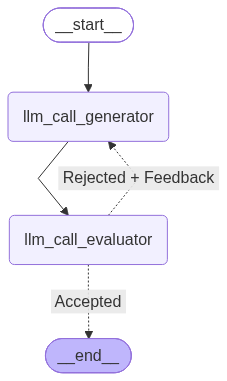

Why did the cat join a band?

Because he wanted to be the **purr**cussionist!


In [13]:
# Graph state
class State(TypedDict):
    joke: str
    topic: str
    feedback: str
    funny_or_not: str


# Schema for structured output to use in evaluation
class Feedback(BaseModel):
    grade: Literal["funny", "not funny"] = Field(
        description="Decide if the joke is funny or not.",
    )
    feedback: str = Field(
        description="If the joke is not funny, provide feedback on how to improve it.",
    )


# Augment the LLM with schema for structured output
evaluator = llm.with_structured_output(Feedback)


# Nodes
def llm_call_generator(state: State):
    """LLM generates a joke"""

    if state.get("feedback"):
        msg = llm.invoke(
            f"Write a joke about {state['topic']} but take into account the feedback: {state['feedback']}"
        )
    else:
        msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}


def llm_call_evaluator(state: State):
    """LLM evaluates the joke"""

    grade = evaluator.invoke(f"Grade the joke {state['joke']}")
    return {"funny_or_not": grade.grade, "feedback": grade.feedback}


# Conditional edge function to route back to joke generator or end based upon feedback from the evaluator
def route_joke(state: State):
    """Route back to joke generator or end based upon feedback from the evaluator"""

    if state["funny_or_not"] == "funny":
        return "Accepted"
    elif state["funny_or_not"] == "not funny":
        return "Rejected + Feedback"


# Build workflow
optimizer_builder = StateGraph(State)

# Add the nodes
optimizer_builder.add_node("llm_call_generator", llm_call_generator)
optimizer_builder.add_node("llm_call_evaluator", llm_call_evaluator)

# Add edges to connect nodes
optimizer_builder.add_edge(START, "llm_call_generator")
optimizer_builder.add_edge("llm_call_generator", "llm_call_evaluator")
optimizer_builder.add_conditional_edges(
    "llm_call_evaluator",
    route_joke,
    {  # Name returned by route_joke : Name of next node to visit
        "Accepted": END,
        "Rejected + Feedback": "llm_call_generator",
    },
)

# Compile the workflow
optimizer_workflow = optimizer_builder.compile()

# Show the workflow
display(Image(optimizer_workflow.get_graph().draw_mermaid_png()))

# Invoke
state = optimizer_workflow.invoke({"topic": "Cats"})
print(state["joke"])

### Functional API

`Feedback` schema 与 `evaluator` 已在上文 Graph API 中定义, 此处直接复用。

In [14]:
# Nodes
@task
def llm_call_generator(topic: str, feedback: Feedback):
    """LLM generates a joke"""
    if feedback:
        msg = llm.invoke(
            f"Write a joke about {topic} but take into account the feedback: {feedback}"
        )
    else:
        msg = llm.invoke(f"Write a joke about {topic}")
    return msg.content


@task
def llm_call_evaluator(joke: str):
    """LLM evaluates the joke"""
    feedback = evaluator.invoke(f"Grade the joke {joke}")
    return feedback


@entrypoint()
def optimizer_workflow(topic: str):
    feedback = None
    while True:
        joke = llm_call_generator(topic, feedback).result()
        feedback = llm_call_evaluator(joke).result()
        if feedback.grade == "funny":
            break

    return joke

# Invoke
stream = optimizer_workflow.stream_events("Cats", version="v3")
for snapshot in stream.values:
    print(snapshot)
    print("\n")

[{'type': 'text', 'text': 'Why did the cat join a band?\n\nBecause he wanted to be the **purr**cussionist!', 'index': 0}]




## Agents

Agent 通常被实现为 LLM 使用 [tools](https://docs.langchain.com/oss/langchain/tools) 执行操作。它们在持续的反馈循环中运行, 适用于问题与解法都不确定的场景。Agent 比 workflow 拥有更多自主性, 可以自行决定使用哪些 tools 以及如何解决问题。你仍然可以定义可用的 toolset, 以及 agent 行为方式的准则。

![agent.png](https://docs.langchain.com/oss/images/agent.png)

> **注意**
>
> 要开始使用 agents, 请参阅 [快速入门](https://docs.langchain.com/oss/langchain/quickstart), 或进一步了解它们在 LangChain 中的 [工作原理](https://docs.langchain.com/oss/langchain/agents)。

### Using tools

In [15]:
# Define tools
@tool
def multiply(a: int, b: int) -> int:
    """Multiply `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a * b


@tool
def add(a: int, b: int) -> int:
    """Adds `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a + b


@tool
def divide(a: int, b: int) -> float:
    """Divide `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a / b


# Augment the LLM with tools
tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}
llm_with_tools = llm.bind_tools(tools)

### Graph API

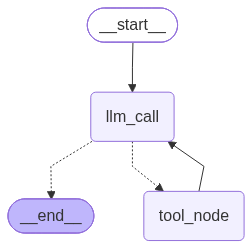

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (call_00_ObkNZ5GgeRqEq49U6WoU5978)
 Call ID: call_00_ObkNZ5GgeRqEq49U6WoU5978
  Args:
    a: 3
    b: 4
================================= Tool Message =================================

7
================================== Ai Message ==================================

3 + 4 = 7


In [16]:
# Nodes
def llm_call(state: MessagesState):
    """LLM decides whether to call a tool or not"""

    return {
        "messages": [
            llm_with_tools.invoke(
                [
                    SystemMessage(
                        content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
                    )
                ]
                + state["messages"]
            )
        ]
    }


def tool_node(state: MessagesState):
    """Performs the tool call"""

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}


# Conditional edge function to route to the tool node or end based upon whether the LLM made a tool call
def should_continue(state: MessagesState) -> Literal["tool_node", END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""

    messages = state["messages"]
    last_message = messages[-1]

    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls:
        return "tool_node"

    # Otherwise, we stop (reply to the user)
    return END


# Build workflow
agent_builder = StateGraph(MessagesState)

# Add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    ["tool_node", END]
)
agent_builder.add_edge("tool_node", "llm_call")

# Compile the agent
agent = agent_builder.compile()

# Show the agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

# Invoke
messages = [HumanMessage(content="Add 3 and 4.")]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()

### Functional API

tools、`llm_with_tools` 与 `tools_by_name` 已在上文定义, 此处直接复用。

In [17]:
@task
def call_llm(messages: list[BaseMessage]):
    """LLM decides whether to call a tool or not"""
    return llm_with_tools.invoke(
        [
            SystemMessage(
                content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
            )
        ]
        + messages
    )


@task
def call_tool(tool_call: ToolCall):
    """Performs the tool call"""
    tool = tools_by_name[tool_call["name"]]
    return tool.invoke(tool_call)


@entrypoint()
def agent(messages: list[BaseMessage]):
    llm_response = call_llm(messages).result()

    while True:
        if not llm_response.tool_calls:
            break

        # Execute tools
        tool_result_futures = [
            call_tool(tool_call) for tool_call in llm_response.tool_calls
        ]
        tool_results = [fut.result() for fut in tool_result_futures]
        messages = add_messages(messages, [llm_response, *tool_results])
        llm_response = call_llm(messages).result()

    messages = add_messages(messages, llm_response)
    return messages

# Invoke
messages = [HumanMessage(content="Add 3 and 4.")]
stream = agent.stream_events(messages, version="v3")
for snapshot in stream.values:
    print(snapshot)
    print("\n")

[HumanMessage(content='Add 3 and 4.', additional_kwargs={}, response_metadata={}, id='9ea93e2c-16e7-4a0b-9e67-859cbb97ea41'), AIMessage(content=[{'type': 'tool_call', 'id': 'call_00_Cvh4FWbXMheVeWEInItB1518', 'name': 'add', 'args': {'a': 3, 'b': 4}}], additional_kwargs={}, response_metadata={'model_provider': 'deepseek', 'finish_reason': 'tool_calls', 'model_name': 'deepseek-flash', 'system_fingerprint': 'aeb56401ca74e127821c4f9126dcb669', 'output_version': 'v1'}, id='lc_run--01a0f853-2e12-7db1-88ec-c880433a9670', tool_calls=[{'name': 'add', 'args': {'a': 3, 'b': 4}, 'id': 'call_00_Cvh4FWbXMheVeWEInItB1518', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 471, 'output_tokens': 52, 'total_tokens': 523, 'input_token_details': {'cache_read': 256}}), ToolMessage(content='7', name='add', id='f852d2b8-2991-4be4-b2de-f4d8c9bc90cc', tool_call_id='call_00_Cvh4FWbXMheVeWEInItB1518'), AIMessage(content=[{'type': 'text', 'text': '3 + 4 = 7', 'index': 0}], additional_k

### ToolNode

`ToolNode` 是一个 prebuilt node, 用于在 LangGraph workflows 中执行 tools。它会自动处理 tool 的并行执行、错误处理与 state 注入。

当你需要对 graph 执行 tools 的方式进行精细控制时, 就使用 `ToolNode`。它是许多 LangGraph agent 模式中 tool 执行能力的构建块。

```python
from langchain.tools import tool
from langgraph.prebuilt import ToolNode
from langgraph.graph import MessagesState, StateGraph

@tool
def search(query: str) -> str:
    """Search for information."""
    return f"Results for: {query}"

@tool
def calculator(expression: str) -> str:
    """Evaluate a math expression."""
    return str(eval(expression))

builder = StateGraph(MessagesState)
builder.add_node("tools", ToolNode([search, calculator]))
# ... add other nodes and edges
graph = builder.compile()
```

#### 从 tools 中访问 graph state 与 context

由 `ToolNode` 执行的 tools 会把 model 生成的参数作为第一个参数接收。要读取并非由 model 生成的 graph 侧数据, 可以使用以下方式之一:

- 在 Python 中, 从注入的 `ToolRuntime` 参数读取 state 与 run 级上下文。
- 在 JavaScript 中, 从 tool 的第二个参数(类型为 `ToolRuntime`)读取 state 与 run 级上下文。

> **注意**
>
> Tools 只能访问传给 `ToolNode` 的 state 取值。当 `ToolNode` 作为 `StateGraph` 的 node 直接添加时, 输入就是当前的 graph state。如果你从另一个 node 手动调用 `ToolNode`, 当 tools 需要自定义的 state 字段时, 请传入完整 state。例如, `tool_node.invoke(state)` 或 `toolNode.invoke(state, config)` 会暴露完整 state, 而只传 `{"messages": state["messages"]}` 或 `{ messages: state.messages }` 则只会暴露 `messages`。

In [18]:
class State(MessagesState):
    user_id: str


@dataclass
class Context:
    organization_id: str


@tool
def get_user_info(runtime: ToolRuntime[Context, State]) -> str:
    """Look up user information."""
    # Read the current graph state passed to the ToolNode.
    user_id = runtime.state["user_id"]

    # Read explicit per-run values that are not part of graph state.
    organization_id = runtime.context.organization_id

    return f"User {user_id} in organization {organization_id}"


builder = StateGraph(State, context_schema=Context)
builder.add_node("tools", ToolNode([get_user_info]))
builder.add_edge(START, "tools")
graph = builder.compile()

result = graph.invoke(
    {
        "messages": [
            AIMessage(
                content="",
                tool_calls=[
                    {
                        "name": "get_user_info",
                        "args": {},
                        "id": "call_user_info",
                    }
                ],
            )
        ],
        "user_id": "user_123",
    },
    context=Context(organization_id="org_456"),
)